# Chriss, *Black-Scholes and Beyond* — replication of the numerical examples

This notebook re-computes the numerical examples, tables and numeric figures of
Neil A. Chriss, *Black-Scholes and Beyond: Option Pricing Models* (Irwin, 1997), chapter by chapter.

**Conventions**

* Everything is computed from the inputs stated in the book — no result is typed in by hand.
  Book values appear **only** as the third argument of `check(...)`, which records *computed vs. book*
  and feeds the reconciliation table at the end of the notebook.
* Binomial trees are stored as `tree[i][j]` with `i` the time step and `j = 0` the **bottom** node,
  exactly the numbering system of Figure 6.7.1. `show_tree` prints them with time running left to right.
* Where the book is internally inconsistent (misprints, rounded intermediate values), the notebook says so
  and shows the value that follows from the stated inputs. Those rows are tagged `DIFF` / `ERRATUM` in the final table.
* Only `numpy`, `scipy`, `pandas` and `matplotlib` are required.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from math import log, sqrt, exp, comb, factorial
from datetime import date
from scipy.stats import norm
from scipy.optimize import brentq, least_squares

pd.set_option("display.width", 160); pd.set_option("display.max_rows", 400)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})

RESULTS = []
def check(item, computed, book, tol=0.006, note=""):
    """Record computed-vs-book. tol is an absolute tolerance (default: half a cent on 2-decimal prints)."""
    computed = float(computed); diff = computed - book
    status = "OK" if abs(diff) <= tol else ("ERRATUM" if note.startswith("erratum") else "DIFF")
    RESULTS.append(dict(chapter=CHAPTER, item=item, computed=computed, book=book, diff=diff, status=status, note=note))
    print(f"{item:<58s} computed = {computed:>12.5f}   book = {book:>10.5g}   [{status}]")
    return computed

## 0. Core library
Black-Scholes formula and Greeks (Display 4.10.1), and the binomial-tree machinery of Chapters 6-7
(Display 6.5.1, eq. 6.8.2, Display 6.11.1, eq. 7.3.4, Display 7.9.1).

In [2]:
# ---------- Black-Scholes (Display 4.10.1) ----------
def bs_d1d2(S, K, T, r, sigma, q=0.0):
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return d1, d1 - sigma * np.sqrt(T)

def bs_price(S, K, T, r, sigma, kind="call", q=0.0):
    d1, d2 = bs_d1d2(S, K, T, r, sigma, q)
    if kind == "call":
        return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)

def bs_greeks(S, K, T, r, sigma, kind="call", q=0.0):
    d1, d2 = bs_d1d2(S, K, T, r, sigma, q)
    eq, er, sT = np.exp(-q * T), np.exp(-r * T), np.sqrt(T)
    gamma = norm.pdf(d1) * eq / (S * sigma * sT)
    vega = S * sT * norm.pdf(d1) * eq
    if kind == "call":
        delta = eq * norm.cdf(d1)
        theta = -S * norm.pdf(d1) * sigma * eq / (2 * sT) - r * K * er * norm.cdf(d2) + q * S * norm.cdf(d1) * eq
        rho = K * T * er * norm.cdf(d2)
    else:
        delta = eq * (norm.cdf(d1) - 1)
        theta = -S * norm.pdf(d1) * sigma * eq / (2 * sT) + r * K * er * norm.cdf(-d2) - q * S * norm.cdf(-d1) * eq
        rho = -K * T * er * norm.cdf(-d2)
    return dict(delta=delta, gamma=gamma, vega=vega, theta=theta, rho=rho)

# ---------- binomial trees: tree[i][j], j = 0 is the bottom node (Figure 6.7.1) ----------
def crr_params(sigma, r, dt):
    """Cox-Ross-Rubinstein: u, d, p (Display 6.5.1)"""
    u = np.exp(sigma * np.sqrt(dt)); d = 1 / u
    return u, d, (np.exp(r * dt) - d) / (u - d)

def eqprob_params(sigma, mu, dt):
    """Equal-probability tree: u, d, p = 1/2 (eqs. 6.5.5-6.5.6)"""
    e = np.exp(2 * sigma * np.sqrt(dt))
    return 2 * np.exp(mu * dt) * e / (e + 1), 2 * np.exp(mu * dt) / (e + 1), 0.5

def standard_tree(S0, u, d, n):
    return [S0 * u ** np.arange(i + 1) * d ** (i - np.arange(i + 1)) for i in range(n + 1)]

def rn_probs(tree, r, dt, div=None):
    """risk-neutral up-probability at every node, eq. (6.8.2); with dollar dividends eq. (9.5.1)"""
    out = []
    for i in range(len(tree) - 1):
        D = 0.0 if div is None else div[i + 1]
        out.append((np.exp(r * dt) * tree[i] - D - tree[i + 1][:-1]) / (tree[i + 1][1:] - tree[i + 1][:-1]))
    return out

def local_vols(tree, probs, dt):
    """local volatility at every node, eq. (6.4.2)"""
    return [np.sqrt(p * (1 - p)) * np.log(tree[i + 1][1:] / tree[i + 1][:-1]) / np.sqrt(dt) for i, p in enumerate(probs)]

def arrow_debreu(probs, r, dt):
    """forward induction of Arrow-Debreu prices, Display 6.11.1"""
    lam = [np.array([1.0])]
    for p in probs:
        prev = lam[-1]; new = np.zeros(len(prev) + 1)
        new[1:] += prev * p; new[:-1] += prev * (1 - p)
        lam.append(np.exp(-r * dt) * new)
    return lam

def payoff_fn(K, kind):
    return (lambda S: np.maximum(S - K, 0.0)) if kind == "call" else (lambda S: np.maximum(K - S, 0.0))

def backward(tree, probs, r, dt, payoff, american=False):
    """backward induction (eq. 7.3.4); american=True adds the early-exercise test (Display 7.9.1)"""
    V = [None] * len(tree); V[-1] = payoff(tree[-1])
    for i in range(len(tree) - 2, -1, -1):
        hold = np.exp(-r * dt) * (probs[i] * V[i + 1][1:] + (1 - probs[i]) * V[i + 1][:-1])
        V[i] = np.maximum(hold, payoff(tree[i])) if american else hold
    return V

def crr_price(S0, K, T, r, sigma, n, kind="call", american=False, full=False):
    dt = T / n; u, d, p = crr_params(sigma, r, dt)
    tree = standard_tree(S0, u, d, n); probs = [np.full(i + 1, p) for i in range(n)]
    V = backward(tree, probs, r, dt, payoff_fn(K, kind), american)
    return (tree, V) if full else V[0][0]

def show_tree(tree, fmt="{:.2f}", title=None):
    """print a recombining tree, time from left to right, highest node on top"""
    n = max(len(l) for l in tree); cols = len(tree)
    grid = [["" for _ in range(cols)] for _ in range(2 * n - 1)]
    for i, lvl in enumerate(tree):
        for j, v in enumerate(lvl):
            if v is None or np.isnan(v): continue
            grid[(n - 1) - (2 * j - i)][i] = fmt.format(v)
    grid = [row for row in grid if any(row)]
    if title: print(title)
    print(pd.DataFrame(grid, columns=[f"t{i}" for i in range(cols)]).to_string(index=False)); print()

## Chapter 1 — Stocks, options and futures

In [3]:
CHAPTER = 1
# --- p.18: index points and a 1% dividend yield
level = 581.0; shares = 10
print("index points owned:", shares * level, "  1% yield is worth", 0.01 * shares * level, "index points")

# --- pp.20-21: dividend reinvestment, q = 5% paid in N = 4 instalments
q, N = 0.05, 4
units = np.cumprod(np.full(N, 1 + q / N))
for k, x in enumerate(units, 1): print(f"units after payment {k}: {x:.4f}")
check("p.21 units after 4 reinvested payments", units[-1], 1.0510, 5e-4)
print(f"first payment if the level is 625: {q / N * 625:.2f} index points;  continuous limit e^q = {np.exp(q):.4f}")

# --- p.22: foreign currency as a security paying the foreign rate
check("p.22 100 yen at 1% for one year", 100 * np.exp(0.01), 101.005, 5e-4)
print("100,000 yen bought at $0.010, sold at $0.011:", 100_000 * 0.011, "USD  -> return", 0.011 / 0.010 - 1)

index points owned: 5810.0   1% yield is worth 58.1 index points
units after payment 1: 1.0125
units after payment 2: 1.0252
units after payment 3: 1.0380
units after payment 4: 1.0509
p.21 units after 4 reinvested payments                     computed =      1.05095   book =      1.051   [OK]
first payment if the level is 625: 7.81 index points;  continuous limit e^q = 1.0513
p.22 100 yen at 1% for one year                            computed =    101.00502   book =        101   [OK]
100,000 yen bought at $0.010, sold at $0.011: 1100.0 USD  -> return 0.09999999999999987


In [4]:
# --- p.29: intrinsic value and time value
S, K, prem = 105, 100, 14.55
intrinsic = max(S - K, 0); time_value = prem - intrinsic
check("p.29 intrinsic value", intrinsic, 5); check("p.29 time value", time_value, 9.55)
print(f"time value / premium = {time_value / prem:.1%}")

# --- p.37: P&L of a short position held over an ex-dividend date
r, S0, D, S2 = 0.05, 100, 1, 90
pnl = np.exp(r * 6 / 12) * S0 - np.exp(r * 3 / 12) * D - S2
check("p.37 short-sale profit", pnl, 11.52)

p.29 intrinsic value                                       computed =      5.00000   book =          5   [OK]
p.29 time value                                            computed =      9.55000   book =       9.55   [OK]
time value / premium = 65.6%
p.37 short-sale profit                                     computed =     11.51893   book =      11.52   [OK]


11.518933600902258

In [5]:
# --- pp.42-44: put-call parity arbitrage
C, P, S, K, T, r = 8.60, 3.50, 100, 100, 1.0, 0.05
bond = np.exp(-r * T) * K
check("p.42 C - P", C - P, 5.10); check("p.42 S - exp(-rT) K", S - bond, 4.88)
check("p.42 riskless profit", (C - P) - (S - bond), 0.22)
cash = 0.0
for step, flow in [("sell the call", C), ("buy the put", -P), ("sell the bond", bond), ("buy the stock", -S)]:
    cash += flow; print(f"{step:<15s} cash flow {flow:>8.2f}   remaining funds {cash:>7.2f}")
check("p.44 bond proceeds", bond, 95.12)

# American counter-example (p.43): the call is exercised against us at 103 after six months, stock ends at 100
owed_on_exercise = 103 - K                      # financed by selling more bond
print("debt left at expiration if the stock falls back to 100:", owed_on_exercise, "-> the arbitrage fails")

p.42 C - P                                                 computed =      5.10000   book =        5.1   [OK]
p.42 S - exp(-rT) K                                        computed =      4.87706   book =       4.88   [OK]
p.42 riskless profit                                       computed =      0.22294   book =       0.22   [OK]
sell the call   cash flow     8.60   remaining funds    8.60
buy the put     cash flow    -3.50   remaining funds    5.10
sell the bond   cash flow    95.12   remaining funds  100.22
buy the stock   cash flow  -100.00   remaining funds    0.22
p.44 bond proceeds                                         computed =     95.12294   book =      95.12   [OK]
debt left at expiration if the stock falls back to 100: 3 -> the arbitrage fails


## Chapter 2 — Fundamental mathematical concepts

In [6]:
CHAPTER = 2
# --- Table 2.1.1: the compounding multiplier (1 + r/n)^n
r = 0.05
tab = pd.DataFrame({"n": [1, 10, 50, 100, 500, 1_000, 10_000, 1_000_000]})
tab["multiplier"] = (1 + r / tab.n) ** tab.n
print(tab.to_string(index=False, float_format="{:.14f}".format)); print(f"limit e^r = {np.exp(r):.14f}")
book = [1.05, 1.05114013204079, 1.05124483243475, 1.05125795994804, 1.05126846837676, 1.05126978233189, 1.05127096496793, 1.05127109497591]
for n, m, b in zip(tab.n, tab.multiplier, book): check(f"Table 2.1.1 n = {n}", m, b, 5e-9)

      n       multiplier
      1 1.05000000000000
     10 1.05114013204079
     50 1.05124483243475
    100 1.05125795994804
    500 1.05126846837676
   1000 1.05126978233189
  10000 1.05127096496793
1000000 1.05127109497591
limit e^r = 1.05127109637602
Table 2.1.1 n = 1                                          computed =      1.05000   book =       1.05   [OK]
Table 2.1.1 n = 10                                         computed =      1.05114   book =     1.0511   [OK]
Table 2.1.1 n = 50                                         computed =      1.05124   book =     1.0512   [OK]
Table 2.1.1 n = 100                                        computed =      1.05126   book =     1.0513   [OK]
Table 2.1.1 n = 500                                        computed =      1.05127   book =     1.0513   [OK]
Table 2.1.1 n = 1000                                       computed =      1.05127   book =     1.0513   [OK]
Table 2.1.1 n = 10000                                      computed =      1.05127   b

In [7]:
# --- p.62: fractional compounding, 7/8 of a year at r1 compounded quarterly  (illustrated with r1 = 8%)
r1, n = 0.08, 4
print("(1+r1/4)^3 * (1+r1/4)^0.5 =", (1 + r1 / n) ** 3 * (1 + r1 / n) ** .5, " = (1+r1/4)^3.5 =", (1 + r1 / n) ** 3.5)
# --- Display 2.1.1: rate conversions
to_cont = lambda r1, n: n * np.log(1 + r1 / n); from_cont = lambda r, n: n * (np.exp(r / n) - 1)
print("8% quarterly -> continuous:", to_cont(0.08, 4), "  and back:", from_cont(to_cont(0.08, 4), 4))
# --- p.66: annualised continuously compounded return, eq. (2.1.1)
check("p.66 return on 100 -> 110 in six months", np.log(110 / 100) / 0.5, 0.19062, 5e-6)

(1+r1/4)^3 * (1+r1/4)^0.5 = 1.0717675436629346  = (1+r1/4)^3.5 = 1.0717675436629344
8% quarterly -> continuous: 0.07921050918471892   and back: 0.08000000000000007
p.66 return on 100 -> 110 in six months                    computed =      0.19062   book =    0.19062   [OK]


0.19062035960864987

In [8]:
# --- Table 2.2.1: expected return and expected price
chg = np.array([-.20, -.10, 0, .10, .20]); prob = np.array([.15, .20, .30, .20, .15]); S0 = 100
check("p.72 expected return", prob @ chg, 0.0, 1e-12); check("p.73 expected price", prob @ (S0 * (1 + chg)), 100, 1e-9)
print("binomial example p.72:", 0.62 * 110 + 0.38 * 90)

# --- Table 2.2.2 / Display 2.2.3: two models with the same mean
def mean_sd(x, p): m = p @ x; return m, np.sqrt(p @ (x - m) ** 2)
m1, s1 = mean_sd(np.array([-.12, .20]), np.array([.375, .625]))
m2, s2 = mean_sd(np.array([-.20, .35]), np.array([.4909, .5091]))
check("Table 2.2.2 mean, model 1", m1, 0.08, 5e-4); check("Table 2.2.2 mean, model 2", m2, 0.08, 5e-4)
check("Display 2.2.3 st.dev., model 1", s1, 0.1549, 5e-5); check("Display 2.2.3 st.dev., model 2", s2, 0.2750, 5e-5)

# --- p.78: probability of the path up-down-up, and of ending on the node it leads to
p = 0.65
check("p.78 probability of one path (u,d,u)", p * (1 - p) * p, 0.1479, 5e-5)
print("probability of the node (3 paths):", comb(3, 2) * p**2 * (1 - p))

p.72 expected return                                       computed =      0.00000   book =          0   [OK]
p.73 expected price                                        computed =    100.00000   book =        100   [OK]
binomial example p.72: 102.4
Table 2.2.2 mean, model 1                                  computed =      0.08000   book =       0.08   [OK]
Table 2.2.2 mean, model 2                                  computed =      0.08000   book =       0.08   [OK]
Display 2.2.3 st.dev., model 1                             computed =      0.15492   book =     0.1549   [OK]
Display 2.2.3 st.dev., model 2                             computed =      0.27495   book =      0.275   [OK]
p.78 probability of one path (u,d,u)                       computed =      0.14787   book =     0.1479   [OK]
probability of the node (3 paths): 0.443625


In [9]:
# --- pp.87-88: probability of a loss when the return is N(10%, 20%)
check("p.88 N(-0.50)", norm.cdf((0 - 0.10) / 0.20), 0.3085, 5e-5)

# --- Displays 2.5.1 and 2.5.2: the four approximations to N(x)
def N_poly1(x):
    a = [0.4361836, -0.1201676, 0.9372980]; t = 1 / (1 + 0.33267 * abs(x))
    v = 1 - norm.pdf(x) * np.polyval(a[::-1] + [0], t); return v if x >= 0 else 1 - v
def N_poly2(x):
    b = [0.319381530, -0.356563782, 1.781477937, -1.821255978, 1.330274429]; t = 1 / (1 + 0.2316419 * abs(x))
    v = 1 - norm.pdf(x) * np.polyval(b[::-1] + [0], t); return v if x >= 0 else 1 - v
def N_rat1(x):
    c = [0.196854, 0.115194, 0.000344, 0.019527]; v = 1 - 0.5 * (1 + np.polyval(c[::-1] + [0], abs(x))) ** -4
    return v if x >= 0 else 1 - v
def N_rat2(x):
    d = [0.0498673470, 0.0211410061, 0.0032776263, 0.0000380036, 0.0000488906, 0.0000053830]
    v = 1 - 0.5 * (1 + np.polyval(d[::-1] + [0], abs(x))) ** -16; return v if x >= 0 else 1 - v
xs = np.linspace(-5, 5, 2001)
acc = pd.DataFrame({"formula": ["polynomial 1", "polynomial 2", "rational 1", "rational 2"],
                    "N(-0.50)": [f(-0.5) for f in (N_poly1, N_poly2, N_rat1, N_rat2)],
                    "max |error| on [-5,5]": [max(abs(f(x) - norm.cdf(x)) for x in xs) for f in (N_poly1, N_poly2, N_rat1, N_rat2)],
                    "accuracy claimed": ["4 decimals", "6 decimals", "2.5e-4", "1e-7"]})
print(acc.to_string(index=False))
print("symmetry N(x) = 1 - N(-x):", norm.cdf(1.3), 1 - norm.cdf(-1.3), "   N(0) =", norm.cdf(0))

p.88 N(-0.50)                                              computed =      0.30854   book =     0.3085   [OK]


     formula  N(-0.50)  max |error| on [-5,5] accuracy claimed
polynomial 1  0.308549           1.152545e-05       4 decimals
polynomial 2  0.308538           7.450841e-08       6 decimals
  rational 1  0.308305           2.329834e-04           2.5e-4
  rational 2  0.308537           1.302052e-07             1e-7
symmetry N(x) = 1 - N(-x): 0.9031995154143897 0.9031995154143897    N(0) = 0.5


## Chapter 3 — The geometric Brownian motion model

In [10]:
CHAPTER = 3
# --- p.98: annualising a daily standard deviation
check("p.98 0.4187% per day, annualised", 0.004187 * np.sqrt(365), 0.0800, 5e-5)

# --- pp.99-101: why volatility depresses returns
deposit = 100 * 1.10 ** np.arange(5)
jolts = np.array([-.05, .05, -.05, .05]); path = [100.0]
for j in jolts: path += [path[-1] * 1.10 * (1 + j)]
print("no volatility :", np.round(deposit, 2)); print("with +-5% jolts:", np.round(path, 4))
check("p.99 deposit after 4 years", deposit[-1], 146.41); check("p.100 with volatility", path[-1], 145.68)
print("(1.05)(0.95) =", 1.05 * 0.95, "   1 - 0.15^2 =", 1 - 0.15**2, "   1 - 0.50^2 =", 1 - 0.5**2)

# --- pp.102-103: scaling of GBM, mu = 10%, sigma = 20%
mu, sig = 0.10, 0.20
for T, bm, bs_ in [(2, .16, .283), (4, .32, .40)]:
    check(f"p.103 expected {T}-year return", T * (mu - sig**2 / 2), bm, 5e-4); check(f"p.103 st.dev. of {T}-year return", sig * np.sqrt(T), bs_, 5e-4)

p.98 0.4187% per day, annualised                           computed =      0.07999   book =       0.08   [OK]
no volatility : [100.   110.   121.   133.1  146.41]
with +-5% jolts: [100.     104.5    120.6975 126.1289 145.6789]
p.99 deposit after 4 years                                 computed =    146.41000   book =     146.41   [OK]
p.100 with volatility                                      computed =    145.67887   book =     145.68   [OK]
(1.05)(0.95) = 0.9974999999999999    1 - 0.15^2 = 0.9775    1 - 0.50^2 = 0.75
p.103 expected 2-year return                               computed =      0.16000   book =       0.16   [OK]
p.103 st.dev. of 2-year return                             computed =      0.28284   book =      0.283   [OK]
p.103 expected 4-year return                               computed =      0.32000   book =       0.32   [OK]
p.103 st.dev. of 4-year return                             computed =      0.40000   book =        0.4   [OK]


### Tables 3.3.1-3.3.2: historical volatility from 20 closing prices

In [11]:
prices = np.array([50, 50.79, 49.78, 49.12, 48.67, 48.94, 48.69, 49.14, 49.30, 48.68,
                   48.78, 48.33, 47.97, 48.83, 47.82, 46.62, 46.93, 46.02, 45.95, 46.11])
dt = 1 / 365
ret = np.log(prices[1:] / prices[:-1])                           # step 3
print(pd.DataFrame({"day": range(1, 20), "price": prices[:-1], "next": prices[1:], "return %": np.round(100 * ret, 2)}).to_string(index=False))
rbar = ret.mean()                                                # step 4
sigma_hat = np.sqrt(np.sum((ret - rbar) ** 2) / (len(ret) - 1)) / np.sqrt(dt)   # step 5, eq. (3.3.1)
check("p.106 first one-day return", ret[0], 0.0157, 5e-5)
check("p.107 mean daily return (book prints +0.0043, sign misprint)", rbar, -0.0043, 5e-5)
check("p.108 estimated volatility", sigma_hat, 0.2407, 5e-4, note="the book also quotes 23.47% a few lines later (misprint)")
print(f"with 250 trading days instead of 365: {sigma_hat * np.sqrt(250 / 365):.4f}")

 day  price  next  return %
   1  50.00 50.79      1.57
   2  50.79 49.78     -2.01
   3  49.78 49.12     -1.33
   4  49.12 48.67     -0.92
   5  48.67 48.94      0.55
   6  48.94 48.69     -0.51
   7  48.69 49.14      0.92
   8  49.14 49.30      0.33
   9  49.30 48.68     -1.27
  10  48.68 48.78      0.21
  11  48.78 48.33     -0.93
  12  48.33 47.97     -0.75
  13  47.97 48.83      1.78
  14  48.83 47.82     -2.09
  15  47.82 46.62     -2.54
  16  46.62 46.93      0.66
  17  46.93 46.02     -1.96
  18  46.02 45.95     -0.15
  19  45.95 46.11      0.35
p.106 first one-day return                                 computed =      0.01568   book =     0.0157   [OK]
p.107 mean daily return (book prints +0.0043, sign misprint) computed =     -0.00426   book =    -0.0043   [OK]
p.108 estimated volatility                                 computed =      0.24104   book =     0.2407   [OK]
with 250 trading days instead of 365: 0.1995


In [12]:
# --- p.108 and Display 3.3.1: probability that |one-year return| exceeds a
def prob_abs_return(a, mu, sig):
    m = mu - sig**2 / 2
    return norm.cdf((-a - m) / sig) + norm.cdf(-(a - m) / sig)
a = np.array([.025, .05, .10, .20, .50]); mu = 0.12
tab = pd.DataFrame({"change": a, "vol 10%": prob_abs_return(a, mu, .10), "vol 25%": prob_abs_return(a, mu, .25)})
print(tab.to_string(index=False, float_format="{:.4f}".format))
for ai, b10, b25 in zip(a, [.8967, .7916, .5754, .1985, .0001], [.9252, .8511, .7072, .4522, .0593]):
    check(f"p.108 P(|ret| > {ai:.1%}), vol 10%", prob_abs_return(ai, mu, .10), b10, 1e-4)
    check(f"p.108 P(|ret| > {ai:.1%}), vol 25%", prob_abs_return(ai, mu, .25), b25, 1e-4)

 change  vol 10%  vol 25%
 0.0250   0.8967   0.9252
 0.0500   0.7916   0.8510
 0.1000   0.5754   0.7072
 0.2000   0.1985   0.4522
 0.5000   0.0001   0.0592
p.108 P(|ret| > 2.5%), vol 10%                             computed =      0.89670   book =     0.8967   [OK]
p.108 P(|ret| > 2.5%), vol 25%                             computed =      0.92519   book =     0.9252   [OK]
p.108 P(|ret| > 5.0%), vol 10%                             computed =      0.79163   book =     0.7916   [OK]
p.108 P(|ret| > 5.0%), vol 25%                             computed =      0.85104   book =     0.8511   [OK]
p.108 P(|ret| > 10.0%), vol 10%                            computed =      0.57540   book =     0.5754   [OK]
p.108 P(|ret| > 10.0%), vol 25%                            computed =      0.70718   book =     0.7072   [OK]
p.108 P(|ret| > 20.0%), vol 10%                            computed =      0.19848   book =     0.1985   [OK]
p.108 P(|ret| > 20.0%), vol 25%                            computed =     

formula: 0.6050339959810325   Monte Carlo: 0.605373


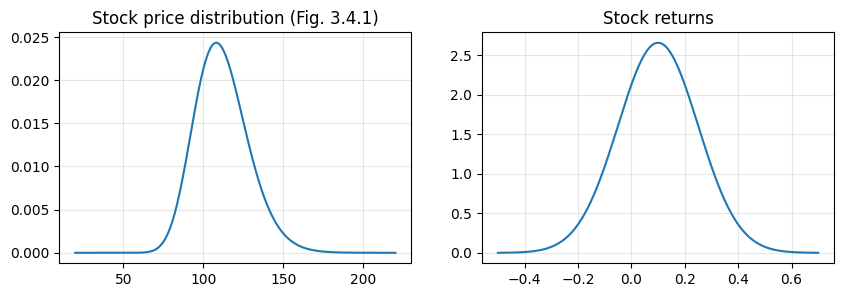

In [13]:
# --- Display 3.5.1: probability that a call expires in the money, checked by simulation
def prob_itm(S, K, T, r, sig): return norm.cdf((np.log(S / K) + (r - sig**2 / 2) * T) / (sig * np.sqrt(T)))
rng = np.random.default_rng(1997)
ST = 100 * np.exp((0.10 - 0.15**2 / 2) * 1 + 0.15 * rng.standard_normal(1_000_000))
print("formula:", prob_itm(100, 105, 1, .10, .15), "  Monte Carlo:", np.mean(ST >= 105))

# Figure 3.4.1: distribution of returns (normal) and prices (log-normal), mu = 10%, sigma = 15%
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
x = np.linspace(20, 220, 400); m, s = np.log(100) + 0.10, 0.15
ax[0].plot(x, norm.pdf((np.log(x) - m) / s) / (x * s)); ax[0].set_title("Stock price distribution (Fig. 3.4.1)")
y = np.linspace(-.5, .7, 400); ax[1].plot(y, norm.pdf(y, .10, .15)); ax[1].set_title("Stock returns"); plt.show()

## Chapter 4 — The Black-Scholes formula

In [14]:
CHAPTER = 4
# --- pp.135-136: the approximate delta, eq. (4.5.1)
S0_, S1_, C0_, C1_, r, dt = 50, 52, 2.00, 2.20, 0.05, 1 / 365
disc = np.exp(-r * dt)
check("p.136 one-day discount factor", disc, 0.99986, 5e-6)
check("p.136 |numerator|  (book drops the minus sign)", abs(C0_ - disc * C1_), 0.199692, 5e-4)
check("p.136 |denominator|", abs(S0_ - disc * S1_), 1.99272, 5e-4)
check("p.136 approximate delta", (C0_ - disc * C1_) / (S0_ - disc * S1_), 0.10021, 5e-4,
      note="book uses the rounded discount factor 0.99986")

p.136 one-day discount factor                              computed =      0.99986   book =    0.99986   [OK]
p.136 |numerator|  (book drops the minus sign)             computed =      0.19970   book =    0.19969   [OK]
p.136 |denominator|                                        computed =      1.99288   book =     1.9927   [OK]
p.136 approximate delta                                    computed =      0.10021   book =    0.10021   [OK]


0.10020619973849017

In [15]:
# --- pp.153-154: sample Black-Scholes computation
S, K, T, sig, r = 100, 100, 1.0, 0.15, 0.05
d1, d2 = bs_d1d2(S, K, T, r, sig)
check("p.153 d1", d1, 0.4083, 5e-5); check("p.153 d2", d2, 0.2583, 5e-5)
check("p.154 N(d1)", norm.cdf(d1), 0.6585, 5e-5); check("p.154 N(d2)", norm.cdf(d2), 0.6019, 5e-5)
C, P = bs_price(S, K, T, r, sig), bs_price(S, K, T, r, sig, "put")
check("p.154 call value", C, 8.595, 5e-3, note="book multiplies 4-decimal N(d): 0.6585*100 - 0.95123*100*0.6019")
check("p.154 put value", P, 3.725, 1.2e-2, note="same rounding of N(d1), N(d2)")
check("p.154 put-call parity C - P", C - P, 4.87, 8e-3); check("p.154 S - exp(-rT) K", S - np.exp(-r * T) * K, 4.87, 8e-3)
print("book's arithmetic with rounded N(.):", 0.6585 * 100 - 0.95123 * 100 * 0.6019)

p.153 d1                                                   computed =      0.40833   book =     0.4083   [OK]


p.153 d2                                                   computed =      0.25833   book =     0.2583   [OK]
p.154 N(d1)                                                computed =      0.65849   book =     0.6585   [OK]
p.154 N(d2)                                                computed =      0.60193   book =     0.6019   [OK]
p.154 call value                                           computed =      8.59166   book =      8.595   [OK]
p.154 put value                                            computed =      3.71460   book =      3.725   [OK]
p.154 put-call parity C - P                                computed =      4.87706   book =       4.87   [OK]
p.154 S - exp(-rT) K                                       computed =      4.87706   book =       4.87   [OK]
book's arithmetic with rounded N(.): 8.595466299999991


### Section 4.9 — lumpy dividends (pp.155-160)

In [16]:
r, S0 = 0.05, 100
div = [(4 / 12, 0.80), (7 / 12, 0.80)]                         # ex-dates 5/1/96 and 8/1/96 seen from 1/1/96
pv = [np.exp(-r * t) * D for t, D in div]
check("p.155 forward value without dividends", S0 * np.exp(r), 105.13)
check("p.156 PV of first dividend", pv[0], 0.787, 5e-4); check("p.156 PV of second dividend", pv[1], 0.777, 5e-4)
check("p.156 forward value with dividends", np.exp(r) * (S0 - sum(pv)), 103.4829, 5e-4, note="book uses PV rounded to 1.564")

def bs_lumpy(S0, K, T, r, sigma, divs, kind="call"):
    """Display 4.9.1: Black-Scholes on S* = S0 - PV(dividends), with sigma* = sigma S0 / S*"""
    Sstar = S0 - sum(np.exp(-r * t) * D for t, D in divs if t <= T)
    return bs_price(Sstar, K, T, r, sigma * S0 / Sstar, kind), Sstar, sigma * S0 / Sstar
val, Sstar, sstar = bs_lumpy(100, 100, 1, 0.05, 0.15, div)     # 15% volatility chosen for illustration (not given in the book)
print(f"one-year 100-strike call, sigma = 15%: no dividends {bs_price(100, 100, 1, .05, .15):.4f};  lumpy dividends {val:.4f}  (S* = {Sstar:.4f}, sigma* = {sstar:.4%})")

# p.158: the stock-minus-bond portfolio P, r = 10%
bond = np.exp(-0.10 * 0.5) * 1
check("p.158 PV of the $1 dividend", bond, 0.95); check("p.158 value of portfolio P", 100 - bond, 99.05)
print("just before ex-date: 104 - 1 =", 104 - 1, ";  just after: (104 - 1) - 0 =", (104 - 1) - 0)

p.155 forward value without dividends                      computed =    105.12711   book =     105.13   [OK]


p.156 PV of first dividend                                 computed =      0.78678   book =      0.787   [OK]
p.156 PV of second dividend                                computed =      0.77700   book =      0.777   [OK]
p.156 forward value with dividends                         computed =    103.48315   book =     103.48   [OK]
one-year 100-strike call, sigma = 15%: no dividends 8.5917;  lumpy dividends 7.6818  (S* = 98.4362, sigma* = 15.2383%)
p.158 PV of the $1 dividend                                computed =      0.95123   book =       0.95   [OK]
p.158 value of portfolio P                                 computed =     99.04877   book =      99.05   [OK]
just before ex-date: 104 - 1 = 103 ;  just after: (104 - 1) - 0 = 103


### Section 4.10 — hedge parameters

In [17]:
# --- pp.163-164: vega as a rate of change
S, K, T, r, sig = 100, 100, 1, 0.10, 0.15
C0 = bs_price(S, K, T, r, sig); C1 = bs_price(S, K, T, r, sig + .01); vega = bs_greeks(S, K, T, r, sig)["vega"]
check("p.163 C(sigma)", C0, 11.67); check("p.163 C(sigma + 1%)", C1, 11.98); check("p.163 vega", vega, 30.30)
check("p.164 C + vega * 0.01", C0 + vega * .01, 11.97)

# --- pp.167-168: three calls, 3 months, sigma = 15%, r = 5%
rows = []
for k, bvega, bval, bchg, bpct in [(100, 19.53, 3.63, .19, 5.23), (110, 5.47, .53, .054, 10.19), (120, 1.67, .03, .016, 53.3)]:
    v = bs_price(100, k, .25, .05, .15); vg = bs_greeks(100, k, .25, .05, .15)["vega"]
    rows.append(dict(strike=k, vega=vg, value=v, chg_1pct=vg / 100, chg_rel_pct=vg / v))
    check(f"p.167 vega, K = {k}", vg, bvega, 0.05, note="erratum: the vega of the 110 call is 11.29, not 5.47; the 1% rows inherit the slip ($0.113, 21%)" if k == 110 else "")
    check(f"p.167 value, K = {k}", v, bval)
print(pd.DataFrame(rows).to_string(index=False, float_format="{:.4f}".format))
print("-> the book's point survives: the relative sensitivity to volatility rises sharply out of the money (5% / 21% / 50%).")

p.163 C(sigma)                                             computed =     11.66913   book =      11.67   [OK]
p.163 C(sigma + 1%)                                        computed =     11.97633   book =      11.98   [OK]
p.163 vega                                                 computed =     30.30149   book =       30.3   [OK]
p.164 C + vega * 0.01                                      computed =     11.97214   book =      11.97   [OK]
p.167 vega, K = 100                                        computed =     19.53568   book =      19.53   [OK]
p.167 value, K = 100                                       computed =      3.63507   book =       3.63   [OK]
p.167 vega, K = 110                                        computed =     11.29351   book =       5.47   [ERRATUM]
p.167 value, K = 110                                       computed =      0.53179   book =       0.53   [OK]
p.167 vega, K = 120                                        computed =      1.67162   book =       1.67   [OK]
p.167

In [18]:
# --- p.171: theta as a rate of change
S, K, T, r, sig = 100, 100, 1, 0.10, 0.15
th = bs_greeks(S, K, T, r, sig)["theta"]
check("p.171 C(T - t)", bs_price(S, K, T, r, sig), 11.67); check("p.171 C one day later", bs_price(S, K, T - 1 / 365, r, sig), 11.65)
check("p.171 theta", th, -8.8142, 5e-3); check("p.171 C + theta / 365", bs_price(S, K, T, r, sig) + th / 365, 11.65)
thc, thp = bs_greeks(90, 100, 1, .10, .15)["theta"], bs_greeks(90, 100, 1, .10, .15, "put")["theta"]
print("put theta = call theta + r K exp(-rT):", thp, thc + .10 * 100 * np.exp(-.10))

# --- p.175: time decay of a two-week at-the-money call (S = K = 100, sigma = 15%, r = 5%)
days = np.arange(14, 0, -1); vals = bs_price(100, 100, days / 365, .05, .15)
book = [1.2693, 1.2197, 1.1684, 1.1153, 1.0600, 1.0022, .9415, .8773, .8089, .7351, .6543, .5634, .4569, .3202]
print(pd.DataFrame({"days": days, "BS value": vals, "book": book}).to_string(index=False, float_format="{:.4f}".format))
for dd, v, b in zip(days, vals, book): check(f"p.175 value with {dd} days left", v, b, 5e-4)

p.171 C(T - t)                                             computed =     11.66913   book =      11.67   [OK]
p.171 C one day later                                      computed =     11.64497   book =      11.65   [OK]
p.171 theta                                                computed =     -8.81425   book =    -8.8142   [OK]
p.171 C + theta / 365                                      computed =     11.64498   book =      11.65   [OK]
put theta = call theta + r K exp(-rT): 2.2323213627278586 2.232321362727859
 days  BS value   book
   14    1.2691 1.2693
   13    1.2195 1.2197
   12    1.1682 1.1684
   11    1.1151 1.1153
   10    1.0597 1.0600
    9    1.0020 1.0022
    8    0.9413 0.9415
    7    0.8771 0.8773
    6    0.8087 0.8089
    5    0.7349 0.7351
    4    0.6540 0.6543
    3    0.5632 0.5634
    2    0.4567 0.4569
    1    0.3201 0.3202
p.175 value with 14 days left                              computed =      1.26910   book =     1.2693   [OK]
p.175 value with 13 days left

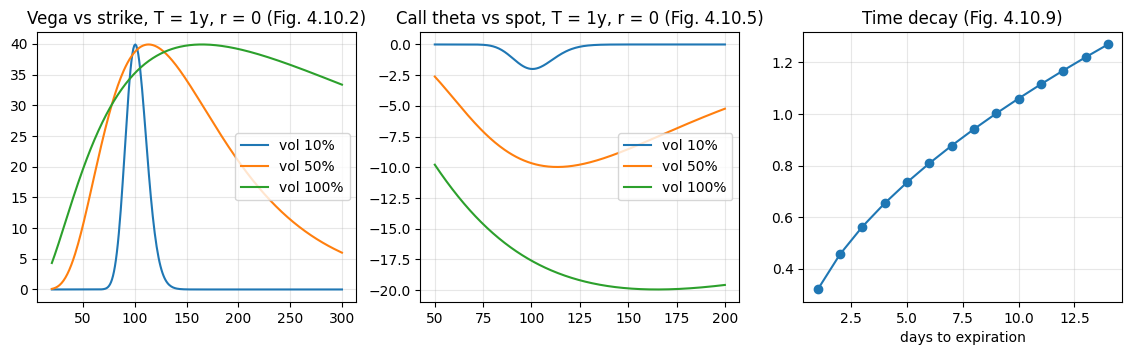

In [19]:
# Figures 4.10.2 / 4.10.5 / 4.10.9 re-drawn
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
k = np.linspace(20, 300, 300)
for s_ in (.10, .50, 1.0): ax[0].plot(k, bs_greeks(100, k, 1, 0, s_)["vega"], label=f"vol {s_:.0%}")
ax[0].set_title("Vega vs strike, T = 1y, r = 0 (Fig. 4.10.2)"); ax[0].legend()
s = np.linspace(50, 200, 300)
for s_ in (.10, .50, 1.0): ax[1].plot(s, bs_greeks(s, 100, 1, 0, s_)["theta"], label=f"vol {s_:.0%}")
ax[1].set_title("Call theta vs spot, T = 1y, r = 0 (Fig. 4.10.5)"); ax[1].legend()
ax[2].plot(days, vals, "o-"); ax[2].set_title("Time decay (Fig. 4.10.9)"); ax[2].set_xlabel("days to expiration"); plt.show()

## Chapter 5 — Simulated Black-Scholes hedging (Tables 5.6.1 - 5.6.10)

A 12-week call, $S_0=K=50$, $\sigma=15\%$, $r=5\%$, is hedged by holding $\Delta=N(d_1)$ shares and a short bond
with par $K\,N(d_2)$. At each rebalancing date

* stock cost $=(\Delta_t-\Delta_{t-1})\,S_t$,
* bond cost $=-K\,[N(d_2)_t-N(d_2)_{t-1}]\,e^{-r\tau_t}$,

and the first row is the set-up cost, i.e. the Black-Scholes price. The weekly stock paths are the ones printed in the book.
Time is measured in days/365 (week $w$ is $7w/365$ years before expiry): that convention reproduces every printed delta.
The book's "Total cost" is the plain (undiscounted) sum of the *Total* column; the weekly figures it prints were evidently
added up from the rounded column entries (and with small slips), so they agree with the exact sums only to within 2-3 cents.
The value of all costs carried to expiration at the risk-free rate is shown as well.

In [20]:
CHAPTER = 5
print("p.202: $10,000 one-year bond at 5%:", round(10_000 * np.exp(-.05)), "  at 4%:", round(10_000 * np.exp(-.04)))

PATHS = {
 "5.6.1": [50, 49.375, 49.375, 51.125, 52.125, 53.375, 52, 50.75, 51.5, 52.625, 53.625, 52.875, 53.125],
 "5.6.3": [50, 49.75, 49.25, 48.5, 48.5, 50.25, 51.625, 50.5, 51, 49.25, 50.875, 50.25, 50],
 "5.6.5": [50, 49.75, 49.875, 48.5, 49, 49.25, 50, 48.5, 48.25, 47.25, 46.375, 47.875, 46.75],
 "5.6.7": [50, 48.375, 47, 46.125, 47.625, 48.625, 50.75, 52.125, 53.875, 54.625, 53.875, 53.625, 53.125],
 "5.6.9": [50, 49.5, 42.375, 43.375, 43.375, 44, 44, 45.125, 46.25, 47, 46.5, 46, 45]}
BOOK_TOTAL = {"5.6.1": (1.79, 1.86), "5.6.3": (1.45, 1.24), "5.6.5": (1.62, 1.74), "5.6.7": (2.30, 2.94), "5.6.9": (3.97, 4.43)}

def hedge_table(path, K=50, r=.05, sigma=.15, weeks=12, step=1):
    path = np.asarray(path, float)[::step]; tau = 7 * np.arange(weeks, -1, -step) / 365          # the book measures time in days/365
    delta, P = np.empty(len(path)), np.empty(len(path))
    live = tau > 0
    d1, d2 = bs_d1d2(path[live], K, tau[live], r, sigma); delta[live], P[live] = norm.cdf(d1), norm.cdf(d2)
    delta[~live] = P[~live] = np.where(path[~live] > K, 1.0, np.where(path[~live] < K, 0.0, 0.5))   # expiry
    stock = np.diff(delta, prepend=0) * path
    bond = -K * np.diff(P, prepend=0) * np.exp(-r * tau)
    tab = pd.DataFrame({"weeks": (tau * 365 / 7).round().astype(int), "stock": path, "delta": delta, "P": P,
                        "stock cost": stock, "bond cost": bond, "total": stock + bond})
    fv = np.sum((stock + bond) * np.exp(r * tau))               # all costs valued at expiration
    return tab, fv

for name, path in PATHS.items():
    tab, fv = hedge_table(path); tab2, fv2 = hedge_table(path, step=2)
    print(f"\nTable {name}"); print(tab.to_string(index=False, formatters={"stock": "{:.3f}".format, "delta": "{:.4f}".format, "P": "{:.4f}".format,
          "stock cost": "{:.2f}".format, "bond cost": "{:.2f}".format, "total": "{:.2f}".format}))
    print(f"sum of weekly totals = {tab.total.sum():.4f};  valued at expiration = {fv:.4f}")
    check(f"Table {name} set-up cost = BS price", tab.total[0], 1.73)
    check(f"Table {name} total cost, weekly", tab.total.sum(), BOOK_TOTAL[name][0], 0.035, note="book adds the rounded column")
    check(f"Table {name} total cost, every two weeks", tab2.total.sum(), BOOK_TOTAL[name][1], 0.006, note="daily column needs the unpublished daily path")

p.202: $10,000 one-year bond at 5%: 9512   at 4%: 9608

Table 5.6.1
 weeks  stock  delta      P stock cost bond cost total
    12 50.000 0.5777 0.5493      28.88    -27.15  1.73
    11 49.375 0.5020 0.4745      -3.74      3.70 -0.04
    10 49.375 0.4949 0.4688      -0.35      0.28 -0.06
     9 51.125 0.7008 0.6788      10.52    -10.41  0.11
     8 52.125 0.8074 0.7909       5.56     -5.56 -0.01
     7 53.375 0.9096 0.9003       5.45     -5.43  0.02
     6 52.000 0.8184 0.8047      -4.74      4.75  0.01
     5 50.750 0.6726 0.6556      -7.40      7.42  0.02
     4 51.500 0.7952 0.7832       6.32     -6.35 -0.04
     3 52.625 0.9358 0.9311       7.40     -7.37  0.02
     2 53.625 0.9931 0.9925       3.08     -3.06  0.01
     1 52.875 0.9970 0.9968       0.21     -0.21 -0.01
     0 53.125 1.0000 1.0000       0.16     -0.16 -0.00
sum of weekly totals = 1.7749;  valued at expiration = 1.7951
Table 5.6.1 set-up cost = BS price                         computed =      1.73107   book =       1.

In [21]:
# spot-check a few table entries
t1, _ = hedge_table(PATHS["5.6.1"]); t9, _ = hedge_table(PATHS["5.6.9"])
check("Table 5.6.1 delta, week 9", t1.delta[3], 0.7008, 5e-5); check("Table 5.6.1 P, week 9", t1.P[3], 0.6788, 5e-5)
check("Table 5.6.1 stock cost, week 9", t1["stock cost"][3], 10.52); check("Table 5.6.1 bond cost, week 9", t1["bond cost"][3], -10.41)
check("Table 5.6.9 delta, week 10 (after the crash)", t9.delta[2], 0.0097, 1e-4); check("Table 5.6.9 total, week 10", t9.total[2], 2.34)

Table 5.6.1 delta, week 9                                  computed =      0.70080   book =     0.7008   [OK]
Table 5.6.1 P, week 9                                      computed =      0.67881   book =     0.6788   [OK]
Table 5.6.1 stock cost, week 9                             computed =     10.52410   book =      10.52   [OK]
Table 5.6.1 bond cost, week 9                              computed =    -10.41168   book =     -10.41   [OK]
Table 5.6.9 delta, week 10 (after the crash)               computed =      0.00964   book =     0.0097   [OK]
Table 5.6.9 total, week 10                                 computed =      2.34074   book =       2.34   [OK]


2.3407423685113073

### Hedging error versus rebalancing frequency
The "daily" column of Tables 5.6.2-5.6.10 cannot be recomputed because the book does not print the daily paths.
A Monte-Carlo experiment under the book's assumptions shows the general pattern instead: the mean cost is the
Black-Scholes price, and its dispersion shrinks roughly with the square root of the rebalancing frequency.

In [22]:
def hedge_cost_mc(n_steps, n_paths=20_000, S0=50, K=50, r=.05, sigma=.15, T=12 / 52, mu=.08, seed=5):
    rng = np.random.default_rng(seed); dt = T / n_steps
    S = np.full(n_paths, float(S0)); delta = norm.cdf(bs_d1d2(S, K, T, r, sigma)[0])
    cash = -delta * S                                            # money account (negative = borrowed)
    for k in range(1, n_steps + 1):
        S *= np.exp((mu - sigma**2 / 2) * dt + sigma * np.sqrt(dt) * rng.standard_normal(n_paths)); cash *= np.exp(r * dt)
        new = np.where(S > K, 1.0, 0.0) if k == n_steps else norm.cdf(bs_d1d2(S, K, T - k * dt, r, sigma)[0])
        cash -= (new - delta) * S; delta = new
    cash += np.where(S > K, K, 0.0)                              # strike received if exercised
    return -cash * np.exp(-r * T)                                # cost of hedging, valued today
rows = [dict(rebalancing=lab, mean=c.mean(), st_dev=c.std()) for lab, n in [("every two weeks", 6), ("weekly", 12), ("daily", 60), ("4 x daily", 240)]
        for c in [hedge_cost_mc(n)]]
print(pd.DataFrame(rows).to_string(index=False, float_format="{:.4f}".format)); print("Black-Scholes price:", round(bs_price(50, 50, 12 / 52, .05, .15), 4))

    rebalancing   mean  st_dev
every two weeks 1.7335  0.4722
         weekly 1.7369  0.3365
          daily 1.7332  0.1580
      4 x daily 1.7341  0.0798
Black-Scholes price: 1.7339


## Chapter 6 — Binomial trees

In [23]:
CHAPTER = 6
# --- Figure 6.2.1: five-period tree with u = exp(0.025), d = 1/u  (100 -> 102.53 / 97.53)
u = np.exp(0.025); tree = standard_tree(100, u, 1 / u, 5); show_tree(tree, title="Figure 6.2.1")
check("Fig 6.2.1 node (1,1)", tree[1][1], 102.53); check("Fig 6.2.1 node (5,5)", tree[5][5], 113.31); check("Fig 6.2.1 node (5,0)", tree[5][0], 88.25)

# --- Figure 6.5.1: four-period CRR tree, dt = one month, sigma = 15%, r = 10%
dt, sig, r = 1 / 12, 0.15, 0.10
u, d, p = crr_params(sig, r, dt); tree = standard_tree(100, u, d, 4); show_tree(tree, title="Figure 6.5.1")
sloc = np.sqrt(p * (1 - p)) * np.log(u / d) / np.sqrt(dt)
check("Fig 6.5.1 sqrt(dt)", np.sqrt(dt), 0.2887, 5e-5); check("Fig 6.5.1 u", u, 1.0443, 5e-5); check("Fig 6.5.1 d", d, 0.9576, 5e-5)
check("Fig 6.5.1 p", p, 0.5853, 6e-4, note="exact value 0.5858"); check("Fig 6.5.1 local volatility", sloc, 0.147, 1e-3, note="exact value 14.78%"); check("Fig 6.5.1 top node", tree[4][4], 118.91)

# --- p.235: convergence of the CRR local volatility (T = 1, mu = 5%, sigma = 15%)
for n, b in [(10, .1495), (25, .1498), (100, .1499), (200, .1500)]:
    u_, d_, p_ = crr_params(.15, .05, 1 / n)
    check(f"p.235 local vol, {n} periods", np.sqrt(p_ * (1 - p_)) * np.log(u_ / d_) / np.sqrt(1 / n), b, 1e-4)

Figure 6.2.1
    t0     t1     t2     t3     t4     t5
                                   113.31
                            110.52       
                     107.79        107.79
              105.13        105.13       
       102.53        102.53        102.53
100.00        100.00        100.00       
        97.53         97.53         97.53
               95.12         95.12       
                      92.77         92.77
                             90.48       
                                    88.25

Fig 6.2.1 node (1,1)                                       computed =    102.53151   book =     102.53   [OK]
Fig 6.2.1 node (5,5)                                       computed =    113.31485   book =     113.31   [OK]
Fig 6.2.1 node (5,0)                                       computed =     88.24969   book =      88.25   [OK]
Figure 6.5.1
    t0     t1     t2     t3     t4
                            118.91
                     113.87       
              109.05        109.05

In [24]:
# --- pp.236-237: the equal-probabilities method
dt, mu, sig = 0.0833, 0.10, 0.15
u, d, p = eqprob_params(sig, mu, dt)
check("p.237 d", d, 0.964737, 5e-6); check("p.237 u", u, 1.05199, 5e-5)
check("p.237 local volatility recovered", 0.5 * np.log(u / d) / np.sqrt(dt), 0.15, 1e-4, note="book gets 0.149996 from rounded u, d")

# Figure 6.5.2: dt = 0.0167, sigma = 1%, r = 30%
u, d, p = eqprob_params(0.01, 0.30, 0.0167); tree = standard_tree(100, u, d, 4); show_tree(tree, title="Figure 6.5.2")
check("Fig 6.5.2 u", u, 1.0063, 5e-5); check("Fig 6.5.2 d", d, 1.0037, 5e-5); check("Fig 6.5.2 top node", tree[4][4], 102.55); check("Fig 6.5.2 bottom node", tree[4][0], 101.49, 0.01)
check("Fig 6.5.2 local volatility", 0.5 * np.log(u / d) / np.sqrt(0.0167), 0.15, 1e-3,
      note="erratum: the figure repeats '15.00%' (and p = .5853 in one printing) from Fig 6.5.1; the tree has sigma = 1%, p = 1/2")

p.237 d                                                    computed =      0.96474   book =    0.96474   [OK]
p.237 u                                                    computed =      1.05199   book =      1.052   [OK]
p.237 local volatility recovered                           computed =      0.15000   book =       0.15   [OK]
Figure 6.5.2
    t0     t1     t2     t3     t4
                            102.55
                     101.91       
              101.27        102.29
       100.63        101.65       
100.00        101.01        102.02
       100.37        101.38       
              100.75        101.76
                     101.12       
                            101.50

Fig 6.5.2 u                                                computed =      1.00632   book =     1.0063   [OK]
Fig 6.5.2 d                                                computed =      1.00372   book =     1.0037   [OK]
Fig 6.5.2 top node                                         computed =    102.55262   b

0.009999999999999244

### Negative probabilities (pp.238-239)
The text states $\Delta t = 0.0192307$, $\mu = 0.50$, $\sigma = 0.25$, but the numbers it then prints
($F = 100.48$, $S_u = 100.10$, $S_d = 99.90$, $p = 3.005632$) do not follow from those inputs. They are reproduced by
$\mu = 0.25$ and a volatility of about $0.69\%$, which the cell below backs out.

In [25]:
dt = 0.0192307
u, d, p = crr_params(.25, .50, dt); print(f"stated inputs : F = {100 * np.exp(.5 * dt):.2f}, Su = {100 * u:.2f}, Sd = {100 * d:.2f}, p = {p:.4f}   (a perfectly good probability)")
mu = np.log(1.0048) / dt; sig = brentq(lambda s: crr_params(s, 0.25, dt)[2] - 3.005632, 1e-4, .05)
u, d, p = crr_params(sig, .25, dt); ue, de, _ = eqprob_params(sig, .25, dt)
print(f"backed out    : mu = 0.25 (F = 100.48 implies {mu:.4f}), sigma = {sig:.5%}")
check("p.238 forward F", 100 * np.exp(.25 * dt), 100.48); check("p.238 CRR Su", 100 * u, 100.10); check("p.238 CRR Sd", 100 * d, 99.90)
check("p.239 CRR 'probability'", p, 3.005632, 1e-5); check("p.238 equal-prob Sd", 100 * de, 100.38)
check("p.238 equal-prob Su", 100 * ue, 110.94, note="erratum: Su must satisfy (Su + Sd)/2 = F, i.e. Su = 100.58, not 110.94")

stated inputs : F = 100.97, Su = 103.53, Sd = 96.59, p = 0.6306   (a perfectly good probability)
backed out    : mu = 0.25 (F = 100.48 implies 0.2490), sigma = 0.69341%
p.238 forward F                                            computed =    100.48193   book =     100.48   [OK]
p.238 CRR Su                                               computed =    100.09621   book =      100.1   [OK]
p.238 CRR Sd                                               computed =     99.90389   book =       99.9   [OK]
p.239 CRR 'probability'                                    computed =      3.00563   book =     3.0056   [OK]
p.238 equal-prob Sd                                        computed =    100.38530   book =     100.38   [OK]
p.238 equal-prob Su                                        computed =    100.57855   book =     110.94   [ERRATUM]


100.57854754587898

In [26]:
# --- Figure 6.8.1: a flexible tree, r = 5%, dt = 1 year
flex = [np.array(x, float) for x in ([100], [86, 110], [79, 100, 126], [74, 92, 107, 144], [60, 80, 100, 120, 154])]
P = rn_probs(flex, .05, 1.0); LV = local_vols(flex, P, 1.0)
show_tree(flex, title="Figure 6.8.1 stock prices"); show_tree(P, "{:.4f}", "risk-neutral up-probabilities"); show_tree(LV, "{:.2%}", "local volatilities")
bookP = [[.7970], [.5433, .6015], [.5028, .8751, .6811], [.8897, .8358, .6243, .9230]]
bookV = [[.0990], [.1174, .1131], [.1089, .0499, .1376], [.0901, .0827, .0883, .0665]]
for i in range(4):
    for j in range(i + 1):
        check(f"Fig 6.8.1 p({i},{j})", P[i][j], bookP[i][j], 5e-5, note="erratum: misprint, .6811 should read .6881" if (i, j) == (2, 2) else ""); check(f"Fig 6.8.1 local vol ({i},{j})", LV[i][j], bookV[i][j], 5e-5)

Figure 6.8.1 stock prices
    t0     t1     t2     t3     t4
                            154.00
                     144.00       
              126.00        120.00
       110.00        107.00       
100.00        100.00        100.00
        86.00         92.00       
               79.00         80.00
                      74.00       
                             60.00

risk-neutral up-probabilities
    t0     t1     t2     t3
                     0.9230
              0.6881       
       0.6015        0.6243
0.7970        0.8751       
       0.5433        0.8358
              0.5028       
                     0.8897

local volatilities
   t0     t1     t2    t3
                    6.65%
             13.76%      
      11.31%        8.83%
9.90%         4.99%      
      11.74%        8.27%
             10.89%      
                    9.01%

Fig 6.8.1 p(0,0)                                           computed =      0.79696   book =      0.797   [OK]
Fig 6.8.1 local vol (0,0)     

### Section 6.10 — a tree with a known dollar dividend (Figure 6.10.3)

In [27]:
def dividend_tree(S0, sigma, r, dt, n, div):
    """div[i] = dollar dividend with ex-date t_i. Steps 1-4 of pp.255-256."""
    div = np.asarray(div, float); t = np.arange(n + 1) * dt
    pv_after = np.array([np.sum(np.exp(-r * (t[i + 1:] - t[i])) * div[i + 1:]) for i in range(n + 1)])   # $_i
    u, d, p = crr_params(sigma, r, dt)
    base = standard_tree(S0 - pv_after[0], u, d, n)
    return [lvl + pv_after[i] for i, lvl in enumerate(base)], pv_after, p
div = [0, 0, 1.0, 0, 0]
tree_nd = standard_tree(100, *crr_params(.15, .10, 1.0)[:2], 4); tree_d, pv, p = dividend_tree(100, .15, .10, 1.0, 4, div)
show_tree(tree_nd, title="no dividends"); show_tree(tree_d, title="$1 dividend, ex-date t2")
check("p.256 PV of dividend at t0", pv[0], 0.8187, 5e-5); check("p.257 PV of dividend at t1", pv[1], 0.9048, 5e-5)
check("Fig 6.10.3 node (1,1)", tree_d[1][1], 116.13, 0.008); check("Fig 6.10.3 node (2,2)", tree_d[2][2], 133.88); check("Fig 6.10.3 node (4,4)", tree_d[4][4], 180.72)
check("Fig 6.10.3 node (4,0)", tree_d[4][0], 54.43); check("Fig 6.10.3 no-dividend top node", tree_nd[4][4], 182.21)
check("p.257 risk-neutral p", p, 0.8120, 2e-3, note="book prints 0.8120, then uses 0.8118 (the exact value is 0.8119)")
check("p.257 expected value at node (1,1)", p * tree_d[2][2] + (1 - p) * tree_d[2][1], 127.35)
check("p.258 forward price with dividend", np.exp(.10) * (tree_d[1][1] - np.exp(-.10) * 1.0), 127.35)

no dividends
    t0     t1     t2     t3     t4
                            182.21
                     156.83       
              134.99        134.99
       116.18        116.18       
100.00        100.00        100.00
        86.07         86.07       
               74.08         74.08
                      63.76       
                             54.88

$1 dividend, ex-date t2
    t0     t1     t2     t3     t4
                            180.72
                     155.55       
              133.88        133.88
       116.14        115.23       
100.00         99.18         99.18
        86.27         85.37       
               73.48         73.48
                      63.24       
                             54.43

p.256 PV of dividend at t0                                 computed =      0.81873   book =     0.8187   [OK]
p.257 PV of dividend at t1                                 computed =      0.90484   book =     0.9048   [OK]
Fig 6.10.3 node (1,1)                    

127.35127057239812

### Sections 6.11-6.12 — Arrow-Debreu prices and the distribution of returns

In [28]:
# two-step illustration of pp.261-263 on the flexible tree of Figure 6.8.1
lam = arrow_debreu(P, .05, 1.0); p1, p3, p2 = P[0][0], P[1][0], P[1][1]
print("lambda(2,2) =", np.exp(-.10) * p1 * p2, " lambda(2,1) =", np.exp(-.10) * (p1 * (1 - p2) + (1 - p1) * p3), " recursion:", lam[2][::-1])
print("sum of A-D prices at each step = discount factor:", np.round([l.sum() for l in lam], 6), np.round(np.exp(-.05 * np.arange(5)), 6))

# --- Figure 6.12.1: 20-period CRR tree, sigma = 15%, r = 10%, T = 1
n, sig, r = 20, .15, .10; u, d, p = crr_params(sig, r, 1 / n)
ST = standard_tree(100, u, d, n)[-1]; j = np.arange(n + 1)
prob_rn = np.array([comb(n, k) for k in j]) * p**j * (1 - p) ** (n - j); prob_half = np.array([comb(n, k) for k in j]) / 2.0**n
fig612 = pd.DataFrame({"terminal price": ST, "1y return": np.log(ST / 100), "prob (risk-neutral p)": prob_rn, "prob (p = 1/2)": prob_half})[::-1]
print(fig612.to_string(index=False, formatters={"terminal price": "{:.2f}".format, "1y return": "{:+.2%}".format,
      "prob (risk-neutral p)": "{:.5%}".format, "prob (p = 1/2)": "{:.5%}".format}))
check("Fig 6.12.1 top terminal price", ST[-1], 195.58); check("Fig 6.12.1 return of top node", np.log(ST[-1] / 100), .6708, 5e-5)
check("Fig 6.12.1 probability of the middle node", prob_half[10], .1761971, 5e-7,
      note="erratum: the figure lists C(20,k)/2^20, i.e. p = 1/2, not the risk-neutral p = %.4f of the stated CRR tree (and misprints two rows)" % p)
check("p.268 probability of the $50-$65 level", prob_half[:4].sum(), .0012885, 5e-7, note="p = 1/2 convention of the figure")
print(f"with the risk-neutral p = {p:.4f} the $50-$65 level has probability {prob_rn[ST < 65].sum():.5%}")

lambda(2,2) = 0.43377755500858667  lambda(2,1) = 0.38715708998836385  recursion: [0.4338 0.3872 0.0839]
sum of A-D prices at each step = discount factor: [1.     0.9512 0.9048 0.8607 0.8187] [1.     0.9512 0.9048 0.8607 0.8187]
terminal price 1y return prob (risk-neutral p) prob (p = 1/2)
        195.58   +67.08%              0.00115%       0.00010%
        182.89   +60.37%              0.01764%       0.00191%
        171.03   +53.67%              0.12831%       0.01812%
        159.93   +46.96%              0.58953%       0.10872%
        149.55   +40.25%              1.91864%       0.46206%
        139.85   +33.54%              4.70158%       1.47858%
        130.78   +26.83%              9.00087%       3.69644%
        122.29   +20.12%             13.78527%       7.39288%
        114.36   +13.42%             17.15416%      12.01344%
        106.94    +6.71%             17.51496%      16.01791%
        100.00    +0.00%             14.75376%      17.61971%
         93.51    -6.71%    

Fig 6.12.2 P(node (10,0))                                  computed =      0.09766   book =     0.0977   [OK]
Fig 6.12.2 P(node (10,1))                                  computed =      0.97656   book =     0.9766   [OK]
Fig 6.12.2 P(node (10,2))                                  computed =      4.39453   book =     4.3945   [OK]
Fig 6.12.2 P(node (10,3))                                  computed =     11.71875   book =     11.719   [OK]
Fig 6.12.2 P(node (10,4))                                  computed =     20.50781   book =     20.508   [OK]
Fig 6.12.2 P(node (10,5))                                  computed =     24.60938   book =     24.609   [OK]


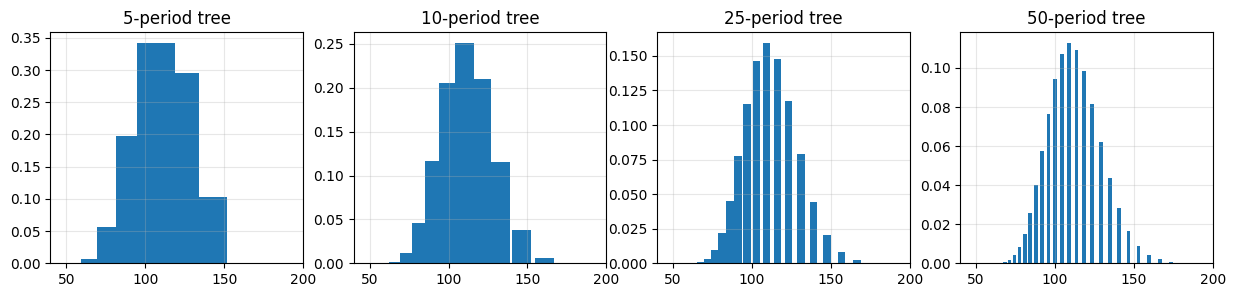

In [29]:
# --- Figure 6.12.2: 10-period equal-probability tree
pr = np.array([comb(10, k) for k in range(11)]) / 2**10
for k, b in zip(range(6), [.0977, .9766, 4.3945, 11.7188, 20.5078, 24.6094]): check(f"Fig 6.12.2 P(node (10,{k}))", 100 * pr[k], b, 5e-5)

# --- Figure 6.12.3: terminal distributions of CRR trees approach the log-normal
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
for a, n in zip(ax, (5, 10, 25, 50)):
    u, d, p = crr_params(.15, .10, 1 / n); k = np.arange(n + 1)
    a.bar(standard_tree(100, u, d, n)[-1], [comb(n, i) * p**i * (1 - p) ** (n - i) for i in k], width=120 / n); a.set_title(f"{n}-period tree"); a.set_xlim(40, 200)
plt.show()

## Chapter 7 — Basic option pricing with binomial trees

In [30]:
CHAPTER = 7
# --- pp.279-281: the one-step model
S0, Su, Sd, K, r, dt = 100, 120, 80, 100, .05, 1.0
Cu, Cd = max(Su - K, 0), max(Sd - K, 0)
p = (np.exp(r * dt) * S0 - Sd) / (Su - Sd); Delta = (Cu - Cd) / (Su - Sd); B = (Su * Cd - Cu * Sd) / (Su - Sd)
check("p.280 risk-neutral p", p, 0.6282, 5e-5); check("p.280 shares of stock", Delta, 0.5, 1e-12); check("p.280 bond par (short)", B, -40, 1e-9)
check("p.280 cost of the stock", Delta * S0, 50.00); check("p.280 proceeds of the bond", -np.exp(-r * dt) * B, 38.05)
check("p.280 option value = cost of hedge, eq (7.1.2)", Delta * S0 + np.exp(-r * dt) * B, 11.95)
check("p.283 same value from eq (7.3.4)", np.exp(-r * dt) * (p * Cu + (1 - p) * Cd), 11.95)
print("replication: up", Delta * Su + B, "= Cu =", Cu, ";  down", Delta * Sd + B, "= Cd =", Cd)

p.280 risk-neutral p                                       computed =      0.62818   book =     0.6282   [OK]
p.280 shares of stock                                      computed =      0.50000   book =        0.5   [OK]
p.280 bond par (short)                                     computed =    -40.00000   book =        -40   [OK]
p.280 cost of the stock                                    computed =     50.00000   book =         50   [OK]
p.280 proceeds of the bond                                 computed =     38.04918   book =      38.05   [OK]
p.280 option value = cost of hedge, eq (7.1.2)             computed =     11.95082   book =      11.95   [OK]
p.283 same value from eq (7.3.4)                           computed =     11.95082   book =      11.95   [OK]
replication: up 20.0 = Cu = 20 ;  down 0.0 = Cd = 0


### Section 7.4 — a $105 call on a four-step flexible tree (Figures 7.4.1-7.4.7)

In [31]:
tree74 = [np.array(x, float) for x in ([100], [91, 110], [86, 101, 112], [74, 92, 107, 134], [70, 80, 101, 122, 142])]
r, dt = .05, 1 / 12
P74 = rn_probs(tree74, r, dt); V74 = backward(tree74, P74, r, dt, payoff_fn(105, "call"))
show_tree(tree74, title="stock price tree"); show_tree(P74, "{:.4f}", "risk-neutral probabilities"); show_tree(V74, title="call value tree (Figure 7.4.6)")
for (i, j), b in {(3, 3): .6280, (3, 2): .3070, (3, 1): .5897, (3, 0): .4309, (2, 2): .2025, (2, 1): .6281, (2, 0): .6866, (1, 1): .8599, (1, 0): .3587, (0, 0): .4957}.items():
    check(f"p.285-288 p({i},{j})", P74[i][j], b, 1e-4)
for (i, j), b in {(3, 3): 29.44, (3, 2): 5.20, (2, 2): 10.07, (2, 1): 3.25, (1, 1): 9.08, (1, 0): 1.16, (0, 0): 5.06}.items():
    check(f"Fig 7.4.6 C({i},{j})", V74[i][j], b, 0.011)

stock price tree
    t0     t1     t2     t3     t4
                            142.00
                     134.00       
              112.00        122.00
       110.00        107.00       
100.00        101.00        101.00
        91.00         92.00       
               86.00         80.00
                      74.00       
                             70.00

risk-neutral probabilities
    t0     t1     t2     t3
                     0.6280
              0.2025       
       0.8599        0.3070
0.4957        0.6281       
       0.3587        0.5897
              0.6866       
                     0.4309

call value tree (Figure 7.4.6)
  t0   t1    t2    t3    t4
                      37.00
                29.44      
          10.06       17.00
     9.07        5.20      
5.06       3.25        0.00
     1.16        0.00      
           0.00        0.00
                 0.00      
                       0.00

p.285-288 p(3,3)                                           computed 

In [32]:
# --- pp.290-292: hedging along the sample path 100 -> 110 -> 101 -> 92
def hedge(i, j, tree, V):
    Su, Sd, Cu, Cd = tree[i + 1][j + 1], tree[i + 1][j], V[i + 1][j + 1], V[i + 1][j]
    return (Cu - Cd) / (Su - Sd), (Su * Cd - Cu * Sd) / (Su - Sd)
path = [(0, 0), (1, 1), (2, 1), (3, 1)]; rows = []
for (i, j), (i2, j2) in zip(path[:-1], path[1:]):
    D_, B_ = hedge(i, j, tree74, V74)
    rows.append(dict(node=(i, j), S=tree74[i][j], shares=D_, bond_par=B_, portfolio_value=D_ * tree74[i][j] + np.exp(-r * dt) * B_, option_value=V74[i][j],
                     value_next_step=D_ * tree74[i2][j2] + B_, option_next_step=V74[i2][j2]))
hp = pd.DataFrame(rows); print(hp.to_string(index=False, float_format="{:.4f}".format))
check("p.290 shares at t0", hp.shares[0], 0.4168, 5e-4); check("p.290 bond at t0", -hp.bond_par[0], 36.7726, 0.05, note="book uses option values rounded to cents")
check("p.291 shares at t1", hp.shares[1], 0.6200, 1e-3, note="book uses option values rounded to cents"); check("p.291 bond at t1", -hp.bond_par[1], 59.37, 0.08, note="book uses option values rounded to cents")
check("p.292 shares at t2", hp.shares[2], 0.3467, 5e-4); check("p.292 bond at t2", -hp.bond_par[2], 31.89, 0.02)
print("self-financing: max |portfolio - option| =", np.abs(hp.portfolio_value - hp.option_value).max(), ";  replication error next step =", np.abs(hp.value_next_step - hp.option_next_step).max())

  node        S  shares  bond_par  portfolio_value  option_value  value_next_step  option_next_step
(0, 0) 100.0000  0.4163  -36.7260           5.0609        5.0609           9.0716            9.0716
(1, 1) 110.0000  0.6194  -59.3041           9.0716        9.0716           3.2508            3.2508
(2, 1) 101.0000  0.3465  -31.8756           3.2508        3.2508           0.0000            0.0000
p.290 shares at t0                                         computed =      0.41634   book =     0.4168   [OK]
p.290 bond at t0                                           computed =     36.72598   book =     36.773   [OK]
p.291 shares at t1                                         computed =      0.61936   book =       0.62   [OK]
p.291 bond at t1                                           computed =     59.30406   book =      59.37   [OK]
p.292 shares at t2                                         computed =      0.34647   book =     0.3467   [OK]
p.292 bond at t2                                  

In [33]:
# --- Figure 7.4.8: the $105 European put (the book leaves the interior of the tree blank)
Vput = backward(tree74, P74, r, dt, payoff_fn(105, "put")); show_tree(Vput, title="European put, K = 105")
lam74 = arrow_debreu(P74, r, dt)
print("Section 7.5, value = sum of Arrow-Debreu price x payoff:  call", lam74[-1] @ payoff_fn(105, "call")(tree74[-1]), "  put", lam74[-1] @ payoff_fn(105, "put")(tree74[-1]))
print("other path-independent payoffs (p.295):  digital", lam74[-1] @ (tree74[-1] >= 105), "  log contract", lam74[-1] @ np.log(tree74[-1]),
      "  asset-or-nothing", lam74[-1] @ (tree74[-1] * (tree74[-1] >= 105)))

European put, K = 105
  t0    t1    t2    t3    t4
                        0.00
                  0.00      
            2.19        0.00
      2.77        2.76      
8.33        6.38        4.00
     13.86       12.56      
           18.13       25.00
                 30.56      
                       35.00

Section 7.5, value = sum of Arrow-Debreu price x payoff:  call 5.060877678716791   put 8.325380329986654
other path-independent payoffs (p.295):  digital 0.23498377628128295   log contract 4.530864505695621   asset-or-nothing 29.7341741882515


### Section 7.6 — convergence (Figure 7.6.2) and Section 7.7 — Monte Carlo on a tree

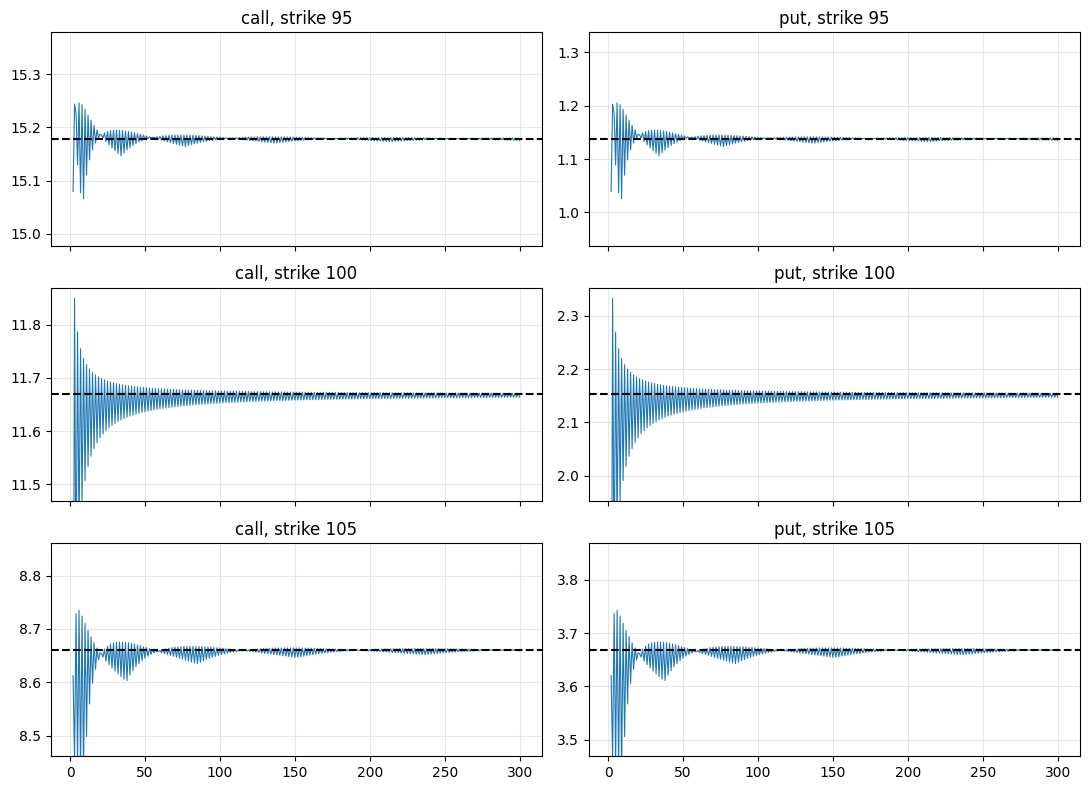

 strike  call_300  call_BS  put_300  put_BS
     95   15.1753  15.1782   1.1349  1.1377
    100   11.6637  11.6691   2.1474  2.1529
    105    8.6591   8.6611   3.6670  3.6690


In [34]:
S0, T, sig, r = 100, 1, .15, .10; ns = np.arange(2, 301)
fig, ax = plt.subplots(3, 2, figsize=(11, 8), sharex=True)
for row, K in enumerate((95, 100, 105)):
    for col, kind in enumerate(("call", "put")):
        ax[row, col].plot(ns, [crr_price(S0, K, T, r, sig, n, kind) for n in ns], lw=.8); ax[row, col].axhline(bs_price(S0, K, T, r, sig, kind), color="k", ls="--")
        ax[row, col].set_title(f"{kind}, strike {K}"); ax[row, col].set_ylim(bs_price(S0, K, T, r, sig, kind) - .2, bs_price(S0, K, T, r, sig, kind) + .2)
plt.tight_layout(); plt.show()
print(pd.DataFrame([dict(strike=K, call_300=crr_price(S0, K, T, r, sig, 300), call_BS=bs_price(S0, K, T, r, sig),
                         put_300=crr_price(S0, K, T, r, sig, 300, "put"), put_BS=bs_price(S0, K, T, r, sig, "put")) for K in (95, 100, 105)]).to_string(index=False, float_format="{:.4f}".format))

In [35]:
# pp.306-307: Monte Carlo on a binomial tree — European lookback call paying S_T - S_min, checked against full path enumeration
def lookback_mc(S0, sig, r, T, n, n_paths, seed=7):
    u, d, p = crr_params(sig, r, T / n); rng = np.random.default_rng(seed)
    ups = rng.random((n_paths, n)) < p
    paths = S0 * np.cumprod(np.where(ups, u, d), axis=1); smin = np.minimum(S0, paths.min(axis=1))
    pay = np.exp(-r * T) * (paths[:, -1] - smin); return pay.mean(), pay.std() / np.sqrt(n_paths)
def lookback_exact(S0, sig, r, T, n):
    u, d, p = crr_params(sig, r, T / n); tot = 0.0
    for m in range(2**n):
        ups = np.array([(m >> k) & 1 for k in range(n)], bool); path = S0 * np.cumprod(np.where(ups, u, d))
        tot += p ** ups.sum() * (1 - p) ** (n - ups.sum()) * (path[-1] - min(S0, path.min()))
    return np.exp(-r * T) * tot
mc, se = lookback_mc(100, .15, .10, 1, 12, 200_000)
print(f"12-step tree: exact enumeration of 2^12 paths = {lookback_exact(100, .15, .10, 1, 12):.4f};  Monte Carlo = {mc:.4f} +- {se:.4f}")
print(f"footnote p.307: a 100-period tree has 2^100 = {2**100:.4e} paths (the book prints 2^(n+1); the number it quotes is 2^100)")

12-step tree: exact enumeration of 2^12 paths = 14.7873;  Monte Carlo = 14.7870 +- 0.0255
footnote p.307: a 100-period tree has 2^100 = 1.2677e+30 paths (the book prints 2^(n+1); the number it quotes is 2^100)


### Section 7.8 — hedge parameters read off the tree (Figure 7.8.2)
$\Delta=(C_u-C_d)/(S_u-S_d)$, $\Gamma$ from the three nodes at $t_2$, and $\Theta=(C_{2,1}-C_{0,0})/(2\Delta t)$ (Rubinstein).

In [36]:
def tree_greeks(S0, K, T, r, sig, n, kind="call"):
    tree, V = crr_price(S0, K, T, r, sig, n, kind, full=True); dt = T / n
    delta = (V[1][1] - V[1][0]) / (tree[1][1] - tree[1][0])
    dU = (V[2][2] - V[2][1]) / (tree[2][2] - tree[2][1]); dD = (V[2][1] - V[2][0]) / (tree[2][1] - tree[2][0])
    gamma = (dU - dD) / (0.5 * (tree[2][2] - tree[2][0])); theta = (V[2][1] - V[0][0]) / (2 * dt)
    return tree, V, delta, gamma, theta
for label, S0, n, bD, bG, bT, bC in [("Jan. 1", 100.0, 90, .56983, .03920, -10.95, 4.57), ("Jan. 2", 100.5, 89, .58768, .03618, -10.95, 4.85)]:
    tree, V, D_, G_, Th_ = tree_greeks(S0, 100, n / 365, .05, .20, n)
    show_tree(tree[:4], title=f"{label}: stock prices"); show_tree(V[:4], title=f"{label}: call values")
    nt = "book's Greeks are computed from node values rounded to cents"
    check(f"Fig 7.8.2 {label} value", V[0][0], bC); check(f"Fig 7.8.2 {label} delta", D_, bD, 2e-3, note=nt); check(f"Fig 7.8.2 {label} gamma", G_, bG, 4e-3, note=nt)
    check(f"Fig 7.8.2 {label} theta", Th_, bT, 0.4, note=nt)
    print(f"   theta from the rounded node values: ({V[2][1]:.2f} - {V[0][0]:.2f}) / (2/365) = {(round(V[2][1], 2) - round(V[0][0], 2)) * 365 / 2:.2f}")
    g = bs_greeks(S0, 100, n / 365, .05, .20); print(f"   Black-Scholes: delta {g['delta']:.5f}, gamma {g['gamma']:.5f}, theta {g['theta']:.3f}\n")
# p.314: the delta/gamma the Jan-1 tree itself predicts for node (1,1) = 101.05
tree, V, *_ = tree_greeks(100.0, 100, 90 / 365, .05, .20, 90)
d11 = (V[2][2] - V[2][1]) / (tree[2][2] - tree[2][1])
d_up = (V[3][3] - V[3][2]) / (tree[3][3] - tree[3][2]); d_dn = (V[3][2] - V[3][1]) / (tree[3][2] - tree[3][1])
check("p.314 delta had the stock gone to 101.05", d11, 0.6085, 2e-3); check("p.314 gamma at that node", (d_up - d_dn) / (0.5 * (tree[3][3] - tree[3][1])), 0.0378, 2e-3)

Jan. 1: stock prices
    t0     t1     t2     t3
                     103.19
              102.12       
       101.05        101.05
100.00        100.00       
        98.96         98.96
               97.93       
                      96.91

Jan. 1: call values
  t0   t1   t2   t3
               6.49
          5.80     
     5.16      5.10
4.57      4.51     
     3.97      3.91
          3.42     
               2.92

Fig 7.8.2 Jan. 1 value                                     computed =      4.56803   book =       4.57   [OK]
Fig 7.8.2 Jan. 1 delta                                     computed =      0.56880   book =    0.56983   [OK]
Fig 7.8.2 Jan. 1 gamma                                     computed =      0.03991   book =     0.0392   [OK]
Fig 7.8.2 Jan. 1 theta                                     computed =    -10.59755   book =     -10.95   [OK]
   theta from the rounded node values: (4.51 - 4.57) / (2/365) = -10.95
   Black-Scholes: delta 0.56899, gamma 0.03957, theta -10.530

0.038786093750999055

### Sections 7.9-7.10 — American options

In [37]:
# --- Figures 7.9.1-7.9.2: two-step CRR tree, American put K = 105
S0, K, T, r, sig, n = 100, 105, 1, .05, .15, 2
u, d, p = crr_params(sig, r, T / n)
check("p.317 u", u, 1.1119, 5e-5); check("p.317 d", d, 0.8994, 5e-5); check("p.317 p", p, 0.5926, 5e-5); check("p.317 discount factor", np.exp(-r * T / n), 0.9753, 5e-5)
tree, Va = crr_price(S0, K, T, r, sig, n, "put", american=True, full=True); _, Ve = crr_price(S0, K, T, r, sig, n, "put", full=True)
show_tree(tree); show_tree(Va, "{:.4f}", "American put"); show_tree(Ve, "{:.4f}", "European put")
check("p.318 node A (holding value)", Ve[1][1], 1.9867, 5e-4); check("p.319 node B, European holding value", Ve[1][0], 12.4694, 6e-3)
check("p.319 node B, exercise value", Va[1][0], 15.06, 6e-3); check("p.319 American put value", Va[0][0], 7.1322, 2e-3, note="book works with 4-decimal u, d, p")

p.317 u                                                    computed =      1.11190   book =     1.1119   [OK]
p.317 d                                                    computed =      0.89937   book =     0.8994   [OK]
p.317 p                                                    computed =      0.59262   book =     0.5926   [OK]
p.317 discount factor                                      computed =      0.97531   book =     0.9753   [OK]
    t0     t1     t2
              123.63
       111.19       
100.00        100.00
        89.94       
               80.89

American put
    t0      t1      t2
                0.0000
        1.9866        
7.1333          5.0000
       15.0635        
               24.1142

European put
    t0      t1      t2
                0.0000
        1.9866        
6.1032          5.0000
       12.4710        
               24.1142

p.318 node A (holding value)                               computed =      1.98660   book =     1.9867   [OK]
p.319 node B, Europ

7.133258570572815

In [38]:
# --- Figures 7.9.3-7.9.4: American put on a flexible tree
flex = [np.array(x, float) for x in ([100], [82, 110], [72, 100, 120])]; r, dt = .05, .5
Pf = rn_probs(flex, r, dt); LVf = local_vols(flex, Pf, dt)
Va = backward(flex, Pf, r, dt, payoff_fn(105, "put"), american=True); Ve = backward(flex, Pf, r, dt, payoff_fn(105, "put"))
show_tree(Va, title="American"); show_tree(Ve, title="European")
check("Fig 7.9.3 exp(r dt)", np.exp(r * dt), 1.0253, 5e-5)
for nm, val, b in [("p_A", Pf[1][1], .63918), ("p_B", Pf[1][0], .4312), ("p_C", Pf[0][0], .7332)]: check(f"Fig 7.9.3 {nm}", val, b, 1.5e-4)
for nm, val, b in [("sigma_A", LVf[1][1], .0418), ("sigma_B", LVf[1][0], .0983), ("sigma_C", LVf[0][0], .0878)]:
    check(f"Fig 7.9.3 {nm}", val, b, 5e-5, note="erratum: the figure shows sqrt(p(1-p)) log(u) (log(1/d) at node C), not the annualised sqrt(p(1-p)) log(u/d)/sqrt(dt) of eq. (6.4.2)")
print("figure's numbers reproduced with sqrt(p(1-p)) * log(u):", [round(float(np.sqrt(q * (1 - q)) * np.log(x)), 4) for q, x in [(Pf[1][1], 120 / 110), (Pf[1][0], 100 / 82), (Pf[0][0], 100 / 82)]])
check("p.320 node A", Va[1][1], 1.76); check("p.320 node B holding value", Ve[1][0], 20.41); check("p.321 node B (exercise)", Va[1][0], 23.00)
check("p.321 American put", Va[0][0], 7.24); check("p.321 European put", Ve[0][0], 6.57)
print("note: the figure prints the bottom terminal node as $70; the ratios (d_B = .8780) and the $33 payoff require $72.")

American
  t0    t1    t2
            0.00
      1.76      
7.24        5.00
     23.00      
           33.00

European
  t0    t1    t2
            0.00
      1.76      
6.57        5.00
     20.41      
           33.00

Fig 7.9.3 exp(r dt)                                        computed =      1.02532   book =     1.0253   [OK]
Fig 7.9.3 p_A                                              computed =      0.63923   book =    0.63918   [OK]
Fig 7.9.3 p_B                                              computed =      0.43128   book =     0.4312   [OK]
Fig 7.9.3 p_C                                              computed =      0.73327   book =     0.7332   [OK]
Fig 7.9.3 sigma_A                                          computed =      0.12382   book =     0.0418   [ERRATUM]
Fig 7.9.3 sigma_B                                          computed =      0.23008   book =     0.0983   [ERRATUM]
Fig 7.9.3 sigma_C                                          computed =      0.18373   book =     0.0878   [

In [39]:
# --- Figures 7.10.1-7.10.2: ten-period American put and the early-exercise barrier
tree, Va = crr_price(100, 100, 1, .10, .15, 10, "put", american=True, full=True)
show_tree(tree, title="Figure 7.10.1"); show_tree(Va, title="Figure 7.10.2")
check("Fig 7.10.1 top node", tree[10][10], 160.70, 0.011); check("Fig 7.10.1 u x 100", tree[1][1], 104.86)
check("Fig 7.10.2 American put value", Va[0][0], 3.08); check("Fig 7.10.2 node (1,0)", Va[1][0], 5.35); check("Fig 7.10.2 node (2,0) = exercise", Va[2][0], 9.05)
barrier = [max((tree[i][j] for j in range(i + 1) if Va[i][j] <= 100 - tree[i][j] + 1e-12 and tree[i][j] < 100), default=np.nan) for i in range(11)]
print("early-exercise barrier (highest exercised node per step):", np.round(barrier, 2))
print("European put on the same tree:", round(crr_price(100, 100, 1, .10, .15, 10, "put"), 4))

Figure 7.10.1
    t0     t1     t2     t3     t4     t5     t6     t7     t8     t9    t10
                                                                      160.70
                                                               153.25       
                                                        146.15        146.15
                                                 139.38        139.38       
                                          132.92        132.92        132.92
                                   126.77        126.77        126.77       
                            120.89        120.89        120.89        120.89
                     115.29        115.29        115.29        115.29       
              109.95        109.95        109.95        109.95        109.95
       104.86        104.86        104.86        104.86        104.86       
100.00        100.00        100.00        100.00        100.00        100.00
        95.37         95.37         95.37         95.37       

## Chapter 8 — The volatility smile: computing implied volatility

In [40]:
CHAPTER = 8
S, K, T, r, mkt = 100, 100, 2, .03, 8.61
# --- p.333: number of bisection steps  k > log(sigma0 / eps) / log 2
for s0, eps, b in [(.5, .1, 2.32), (.5, .01, 5.64), (20, .01, 10.97)]: check(f"p.333-334 log({s0}/{eps})/log 2", np.log(s0 / eps) / np.log(2), b)

# --- Table 8.2.1: the method of bisections
def implied_vol_bisection(price, S, K, T, r, sigma0=.20, steps=10):
    sig, rows = sigma0, []
    for k in range(1, steps + 1):
        sig = sig - sigma0 / 2**k if (k == 1 or bs_price(S, K, T, r, sig) > price) else sig + sigma0 / 2**k
        rows.append(dict(step=k, sigma=sig, BS_price=bs_price(S, K, T, r, sig)))
    return pd.DataFrame(rows)
tab = implied_vol_bisection(mkt, S, K, T, r); print(tab.to_string(index=False, formatters={"sigma": "{:.4%}".format, "BS_price": "{:.4f}".format}))
book = [(.10, 8.87), (.05, 6.58), (.075, 7.66), (.0875, 8.25), (.0938, 8.56), (.0969, 8.71), (.0953, 8.64), (.0945, 8.60), (.0949, 8.62), (.0947, 8.61)]
for (k, row), (bs_, bp) in zip(tab.iterrows(), book):
    check(f"Table 8.2.1 step {k + 1}: sigma", row.sigma, bs_, 5e-5); check(f"Table 8.2.1 step {k + 1}: price", row.BS_price, bp, .011)

p.333-334 log(0.5/0.1)/log 2                               computed =      2.32193   book =       2.32   [OK]
p.333-334 log(0.5/0.01)/log 2                              computed =      5.64386   book =       5.64   [OK]
p.333-334 log(20/0.01)/log 2                               computed =     10.96578   book =      10.97   [OK]
 step    sigma BS_price
    1 10.0000%   8.8692
    2  5.0000%   6.5799
    3  7.5000%   7.6573
    4  8.7500%   8.2530
    5  9.3750%   8.5590
    6  9.6875%   8.7136
    7  9.5313%   8.6362
    8  9.4531%   8.5976
    9  9.4922%   8.6169
   10  9.4727%   8.6072
Table 8.2.1 step 1: sigma                                  computed =      0.10000   book =        0.1   [OK]
Table 8.2.1 step 1: price                                  computed =      8.86916   book =       8.87   [OK]
Table 8.2.1 step 2: sigma                                  computed =      0.05000   book =       0.05   [OK]
Table 8.2.1 step 2: price                                  computed =      6

In [41]:
# --- pp.339-340: Newton-Raphson, eq. (8.3.1)
sig, hist = .20, []
for it in range(4):
    c, v = bs_price(S, K, T, r, sig), bs_greeks(S, K, T, r, sig)["vega"]; hist.append(dict(iteration=it + 1, sigma=sig, C=c, vega=v, next_sigma=sig - (c - mkt) / v)); sig = hist[-1]["next_sigma"]
nr = pd.DataFrame(hist); print(nr.to_string(index=False, float_format="{:.6f}".format))
check("p.340 C(20%)", nr.C[0], 14.0721, 2e-3); check("p.340 vega(20%)", nr.vega[0], 53.0007, 5e-3); check("p.340 sigma_2", nr.next_sigma[0], .0969, 5e-5)
check("p.340 C(sigma_2)", nr.C[1], 8.7144, 2e-3, note="book evaluates at the rounded 9.69%"); check("p.340 vega(sigma_2)", nr.vega[1], 49.6346, 2e-2)
check("p.340 sigma_3", nr.next_sigma[1], .0948, 5e-5); check("p.340 C(sigma_3)", nr.C[2], 8.6103, 2e-3)
print("exact implied volatility:", brentq(lambda s: bs_price(S, K, T, r, s) - mkt, .01, 1))

 iteration    sigma         C      vega  next_sigma
         1 0.200000 14.073636 53.000706    0.096914
         2 0.096914  8.715545 49.631913    0.094787
         3 0.094787  8.610221 49.421627    0.094783
         4 0.094783  8.610000 49.421170    0.094783
p.340 C(20%)                                               computed =     14.07364   book =     14.072   [OK]
p.340 vega(20%)                                            computed =     53.00071   book =     53.001   [OK]
p.340 sigma_2                                              computed =      0.09691   book =     0.0969   [OK]
p.340 C(sigma_2)                                           computed =      8.71554   book =     8.7144   [OK]
p.340 vega(sigma_2)                                        computed =     49.63191   book =     49.635   [OK]
p.340 sigma_3                                              computed =      0.09479   book =     0.0948   [OK]
p.340 C(sigma_3)                                           computed =      8.610

Section 8.5 (stochastic volatility, Figures 8.5.2-8.5.6) contains simulated paths and histograms only; the book does not
specify the mean-reverting process or its parameters, so there are no numbers to replicate there.

## Chapter 9 — Implied volatility trees

In [42]:
CHAPTER = 9
# --- p.367: interpolated vs historical volatility
check("p.367 call at the interpolated vol 15.3%", bs_price(62, 65, .5, .03, .153), 1.82); check("p.367 call at the historical vol 15%", bs_price(62, 65, .5, .03, .15), 1.77)

# --- Section 9.10: bilinear interpolation, Table 9.8.1
STRIKES = np.array([500, 540, 575, 595, 625.0]); EXPIRIES = [date(1995, 10, 20), date(1995, 12, 15), date(1996, 3, 15), date(1996, 6, 21)]
VOLS = np.array([[18.5, 17.5, 17.3, 17.0], [12.0, 13.9, 14.9, 15.1], [10.4, 11.3, 12.9, 13.6], [9.6, 10.4, 12.0, 12.6], [8.2, 9.2, 10.8, 11.4]]) / 100
def days30(d0, d1): return 360 * (d1.year - d0.year) + 30 * (d1.month - d0.month) + (d1.day - d0.day)       # the book counts 30-day months
def bilinear(t_days, K, t_grid, k_grid, v):
    """eq. (9.10.1); flat extrapolation outside the grid"""
    t_days = np.clip(t_days, t_grid[0], t_grid[-1]); K = np.clip(K, k_grid[0], k_grid[-1])
    i = int(np.clip(np.searchsorted(t_grid, t_days) - 1, 0, len(t_grid) - 2)); j = int(np.clip(np.searchsorted(k_grid, K) - 1, 0, len(k_grid) - 2))
    a = (t_days - t_grid[i]) / (t_grid[i + 1] - t_grid[i]); b = (K - k_grid[j]) / (k_grid[j + 1] - k_grid[j])
    return (1 - a) * (1 - b) * v[j, i] + a * (1 - b) * v[j, i + 1] + a * b * v[j + 1, i + 1] + (1 - a) * b * v[j + 1, i]
t0 = date(1995, 9, 1); TGRID = np.array([days30(t0, d) for d in EXPIRIES], float)
print("a =", days30(date(1996, 3, 15), date(1996, 6, 15)), "/", days30(date(1996, 3, 15), date(1996, 6, 21)), "  b = 20/35")
check("p.408 implied vol, K = 560, expiry 6/15/96", 100 * bilinear(days30(t0, date(1996, 6, 15)), 560, TGRID, STRIKES, VOLS), 14.213, 5e-4,
      note="the printed formula says 'ab 14.6'; the result uses the table value 13.6")

# --- Figure 9.5.2: replacing a bad node
S_prev = (86.0, 100.0); S_known = 115.0; r = .10
F = np.exp(r) * S_prev[0]; bad = 93.0; new = S_known * S_prev[0] / S_prev[1]
check("Fig 9.5.2 forward of the 86 node", F, 95.04); check("Fig 9.5.2 replacement node", new, 98.90)
print(f"the implied node {bad:.2f} lies below the forward {F:.2f} (bad probability);  the replacement {new:.2f} = 115 x 86 / 100 lies above it")

p.367 call at the interpolated vol 15.3%                   computed =      1.82213   book =       1.82   [OK]
p.367 call at the historical vol 15%                       computed =      1.77124   book =       1.77   [OK]
a = 90 / 96   b = 20/35
p.408 implied vol, K = 560, expiry 6/15/96                 computed =     14.21250   book =     14.213   [OK]
Fig 9.5.2 forward of the 86 node                           computed =     95.04470   book =      95.04   [OK]
Fig 9.5.2 replacement node                                 computed =     98.90000   book =       98.9   [OK]
the implied node 93.00 lies below the forward 95.04 (bad probability);  the replacement 98.90 = 115 x 86 / 100 lies above it


### The tree-building algorithm of Section 9.6 (European input options)
For every new time step: start at the centre (eqs. 9.6.1-9.6.6), move **down** using put prices (eqs. 9.6.8-9.6.9), move **up**
using call prices (eqs. 9.6.10-9.6.11), repair bad probabilities as in Section 9.5, then update the Arrow-Debreu prices.
As in the book's examples, an input option expiring at $t_i$ is priced on an $i$-period CRR tree built with its own implied volatility.
(The false-position search of Sections 9.3-9.4 is only needed for *American* input options, of which the book gives no numerical example.)

In [43]:
def implied_vol_tree(S0, r, dt, n, smile, pricer, center="spot", eps=1e-6):
    tree, lam, probs, fixes, inputs = [np.array([float(S0)])], [np.array([1.0])], [], [], []
    disc, grow = np.exp(-r * dt), np.exp(r * dt)
    for i in range(1, n + 1):
        prev, L, T = tree[-1], lam[-1], i * dt; S = np.full(i + 1, np.nan)
        def opt(j, kind):
            vol = smile(prev[j], T); px = pricer(S0, prev[j], T, r, vol, i, kind); inputs.append(dict(step=i, node=j, kind=kind, strike=prev[j], vol=vol, price=px)); return px
        v_put = lambda j: (opt(j, "put") - np.sum(L[:j] * (disc * prev[j] - prev[:j]))) / L[j]                   # eq. (9.6.8)
        v_call = lambda j: (opt(j, "call") - np.sum(L[j + 1:] * (prev[j + 1:] - disc * prev[j]))) / L[j]         # eq. (9.6.10)
        if i % 2 == 0:                                            # odd number of nodes: fix the middle one
            lo = hi = i // 2; S[lo] = S0 if center == "spot" else S0 * np.exp(r * T)
        else:                                                     # even number: the two central nodes from one put
            j = (i - 1) // 2; v, K = v_put(j), prev[j]; u = (v + K) / (disc * K - v)                             # eq. (9.6.4)
            S[j + 1], S[j] = K * u, (K / u if center == "spot" else K * grow / u); lo, hi = j, j + 1
        for j in range(lo - 1, -1, -1):                           # move down with puts, eq. (9.6.9)
            v, K, Su = v_put(j), prev[j], S[j + 1]; S[j] = (v * Su + (K - disc * Su) * K) / (v + K - disc * Su)
            if not S[j] < grow * K < Su:
                new = Su * prev[j] / prev[j + 1]; new = new if new < grow * K else grow * K - eps; fixes.append((i, j, S[j], new)); S[j] = new
        for j in range(hi, i):                                    # move up with calls, eq. (9.6.11)
            v, K, Sd = v_call(j), prev[j], S[j]; S[j + 1] = (v * Sd + (disc * Sd - K) * K) / (v + disc * Sd - K)
            if not Sd < grow * K < S[j + 1]:
                new = Sd * prev[j] / prev[j - 1]; new = new if new > grow * K else grow * K + eps; fixes.append((i, j + 1, S[j + 1], new)); S[j + 1] = new
        p = (grow * prev - S[:-1]) / (S[1:] - S[:-1]); tree.append(S); probs.append(p)
        lam = lam + [arrow_debreu(probs, r, dt)[-1]]
    return tree, probs, lam, fixes, pd.DataFrame(inputs)
tree_pricer = lambda S0, K, T, r, vol, i, kind: crr_price(S0, K, T, r, vol, i, kind)

### Example 1 — a simple smile (pp.391-395, Figure 9.7.2)

In [44]:
smile1 = lambda K, T: (-K / 20 + 20) / 100 if K <= 110 else (-K / 10 + 25.5) / 100
T1, P1, L1, fixes1, in1 = implied_vol_tree(100, .05, 1.0, 4, smile1, tree_pricer)
show_tree(T1, title="implied stock price tree"); show_tree(L1, "{:.5f}", "Arrow-Debreu prices"); show_tree(local_vols(T1, P1, 1.0), "{:.2%}", "local volatilities"); print("bad nodes repaired:", fixes1)
print(in1.head(4).to_string(index=False, float_format="{:.4f}".format))
check("p.392 P(t1, 100)", in1.price[0], 4.8649, 5e-5); check("p.393 S(1,1)", T1[1][1], 116.1834, 5e-5); check("p.393 S(1,0)", T1[1][0], 86.0708, 5e-5)
check("p.393 p(0,0)", P1[0][0], .6328, 5e-5); check("p.393 lambda(1,1)", L1[1][1], .6020, 5e-5); check("p.393 lambda(1,0)", L1[1][0], .3493, 5e-5)
check("p.393 implied vol of the 86.07 put", 100 * in1.vol[1], 15.70, 5e-3); check("p.393 P(t2, 86.0708)", in1.price[1], 1.6693, 5e-5); check("p.394 S(2,0)", T1[2][0], 70.4897, 2e-3)
check("p.394 implied vol of the 116.18 call", 100 * in1.vol[2], 13.88, 5e-3); check("p.394 C(t2, 116.1834)", in1.price[2], 6.0361, 5e-5); check("p.394 S(2,2)", T1[2][2], 130.89)
nt = "the book carries rounded intermediate values forward"
for (i, j), b in {(3, 3): 143.06, (3, 2): 116.78, (3, 1): 85.63, (3, 0): 60.49, (4, 4): 153.65, (4, 3): 132.04, (4, 1): 71.05, (4, 0): 46.69}.items(): check(f"Fig 9.7.2 S({i},{j})", T1[i][j], b, 0.75, note=nt)
for (i, j), b in {(2, 2): .41040, (2, 1): .38657, (2, 0): .10786, (4, 4): .24990, (4, 3): .25470, (4, 2): .20607, (4, 1): .09437, (4, 0): .01371}.items(): check(f"Fig 9.7.2 lambda({i},{j})", L1[i][j], b, 1.5e-3, note=nt)

implied stock price tree
    t0     t1     t2     t3     t4
                            153.65
                     143.05       
              130.89        132.04
       116.18        116.74       
100.00        100.00        100.00
        86.07         85.66       
               70.49         70.77
                      60.40       
                             45.97

Arrow-Debreu prices
     t0      t1      t2      t3      t4
                                0.25001
                        0.30951        
                0.41040         0.25461
        0.60197         0.31165        
1.00000         0.38730         0.20731
        0.34926         0.19291        
                0.10713         0.09379
                        0.04664        
                                0.01301

local volatilities
    t0     t1     t2     t3
                      5.42%
               8.24%       
       12.13%        12.62%
14.46%        14.97%       
       16.35%        16.38%
              17

max |tree price - input price| = 1.509903313490213e-14


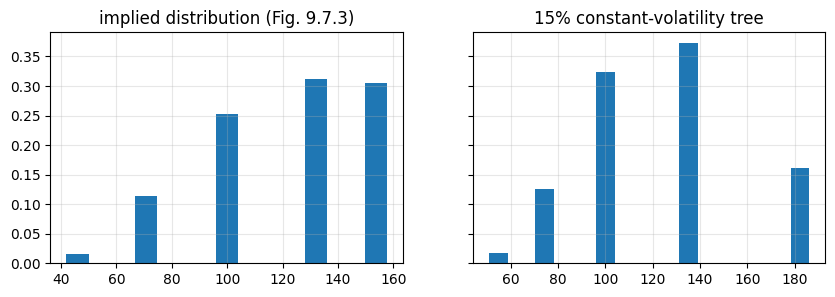

In [45]:
# consistency test the book does not show: the implied tree must re-price every input option
reprice = [L1[int(row.step)] @ payoff_fn(row.strike, row.kind)(T1[int(row.step)]) for row in in1.itertuples()]
print("max |tree price - input price| =", np.abs(np.array(reprice) - in1.price).max())
# Figure 9.7.3: implied distribution vs the at-the-money (15%) CRR tree
u, d, p = crr_params(.15, .05, 1.0); fig, ax = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
ax[0].bar(T1[-1], np.exp(.05 * 4) * L1[-1], width=8); ax[0].set_title("implied distribution (Fig. 9.7.3)")
ax[1].bar(standard_tree(100, u, d, 4)[-1], [comb(4, k) * p**k * (1 - p) ** (4 - k) for k in range(5)], width=8); ax[1].set_title("15% constant-volatility tree"); plt.show()

### Section 9.8 — hypothetical S&P 500 tree (Table 9.8.1, Figure 9.8.1)
Spot 560, $r=5\%$, four quarterly steps from 9/1/95, smile from Table 9.8.1 by bilinear interpolation.
The book gives only the finished figure ("as a control"), and that figure cannot be matched exactly:

* its first step ($595.42/526.69$) corresponds to an implied volatility of 12.27% for the 560-strike option expiring 12/1/95,
  whereas bilinear interpolation of Table 9.8.1 gives 12.08% (30/360) — actual/365 and the two possible start dates (9/1 and 9/15) do not give 12.27% either;
* the three lowest nodes of the figure are all printed as \$337.43. The replication shows where this comes from: the put struck at
  the lowest node is worth (numerically) zero on the small CRR tree used to price it — the figure's option-price tree indeed shows
  \$0.00 there — and with $v=0$ eq. (9.6.9) collapses to $S_{i,j}=K=S_{i-1,j}$, so the bottom node simply repeats itself.

The cell builds the tree that the stated data and algorithm imply and lists it against the figure. The shape (including the
repeated bottom node and the fat left tail) is reproduced; the levels differ by up to about 1-2%.

In [46]:
smile_sp = lambda K, T: bilinear(T * 360, K, TGRID, STRIKES, VOLS)
T2, P2, L2, fixes2, in2 = implied_vol_tree(560, .05, .25, 4, smile_sp, tree_pricer)
show_tree(T2, title="implied S&P 500 tree"); show_tree(L2, "{:.4f}", "Arrow-Debreu prices"); show_tree(local_vols(T2, P2, .25), "{:.2%}", "local volatilities")
print("bad nodes repaired (step, node, implied value, replacement):", [(i, j, round(a, 2), round(b, 2)) for i, j, a, b in fixes2])
print(in2.to_string(index=False, float_format="{:.4f}".format))
nt = "figure not reproducible from Table 9.8.1 (see text)"
check("Fig 9.8.1 vol of the first input option (%)", 100 * in2.vol[0], 12.27, .05, note=nt)
for (i, j), b in {(1, 1): 595.42, (1, 0): 526.69, (2, 2): 629.40, (3, 3): 666.33, (3, 2): 602.30, (3, 1): 520.68, (4, 4): 711.84, (4, 3): 634.10, (4, 1): 471.12, (2, 0): 337.43, (3, 0): 337.43, (4, 0): 337.43}.items(): check(f"Fig 9.8.1 S({i},{j})", T2[i][j], b, 1.0, note=nt)
for (i, j), b in {(1, 1): .5893, (1, 0): .3970, (2, 1): .5614}.items(): check(f"Fig 9.8.1 lambda({i},{j})", L2[i][j], b, 5e-3, note=nt)
u_b = 595.42 / 560; print(f"figure's first step implies sigma = ln(u)/sqrt(dt) = {np.log(u_b) / .5:.4%}; feeding 12.27% into the algorithm gives",
      np.round(implied_vol_tree(560, .05, .25, 1, lambda K, T: .1227, tree_pricer)[0][1], 2))

implied S&P 500 tree
    t0     t1     t2     t3     t4
                            707.71
                     666.32       
              628.68        629.40
       594.85        601.90       
560.00        560.00        560.00
       527.19        521.01       
              329.26        480.74
                     329.26       
                            329.26

Arrow-Debreu prices
    t0     t1     t2     t3     t4
                            0.1076
                     0.1883       
              0.3541        0.4198
       0.5817        0.4850       
1.0000        0.5757        0.2810
       0.4059        0.2460       
              0.0455        0.1006
                     0.0439       
                            0.0422

local volatilities
    t0     t1     t2     t3
                     11.58%
              10.14%       
       11.25%        10.57%
11.88%        14.29%       
       33.69%        15.01%
              13.34%       
                     12.34%

bad nodes rep

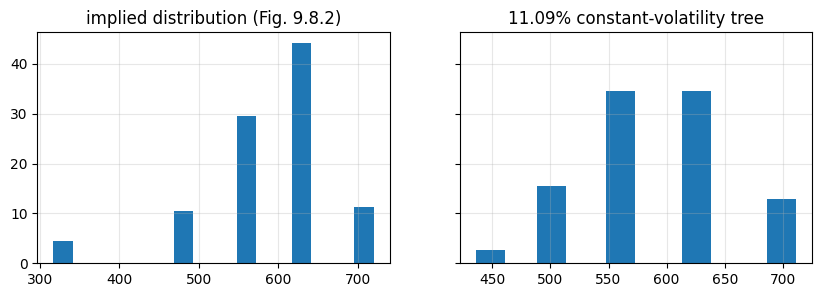

implied probabilities: [0.0444 0.1058 0.2954 0.4413 0.1131]  -> fat left tail


In [47]:
# Figure 9.8.2: implied distribution vs a constant 11.09% tree (the figure's "at-the-money" volatility)
u, d, p = crr_params(.1109, .05, .25); fig, ax = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
ax[0].bar(T2[-1], 100 * np.exp(.05) * L2[-1], width=25); ax[0].set_title("implied distribution (Fig. 9.8.2)")
ax[1].bar(standard_tree(560, u, d, 4)[-1], [100 * comb(4, k) * p**k * (1 - p) ** (4 - k) for k in range(5)], width=25); ax[1].set_title("11.09% constant-volatility tree"); plt.show()
print("implied probabilities:", np.round(np.exp(.05) * L2[-1], 4), " -> fat left tail")

Tables 9.9.1-9.9.2 (skew deltas and American put values, source Goldman Sachs) rest on the full 10/23/95 S&P 500 option
surface, dividends and rates, none of which the book reproduces; they cannot be recomputed from the text.

## Chapter 10 — Implied binomial trees (Rubinstein)

In [48]:
CHAPTER = 10
def solve_qp(P, A, b, fixed=None):
    """min ||Q - P||^2  s.t.  A Q = b, Q >= 0, Q[i] = fixed[i]   (eqs. 10.1.1-10.1.4 and 10.4.1-10.4.6).
    Equality-constrained least squares via its KKT system, with an active-set loop for Q >= 0."""
    P = np.asarray(P, float); n = len(P); fixed = dict(fixed or {}); zero = set()
    for _ in range(n):
        pin = {**{i: 0.0 for i in zero}, **fixed}; free = [i for i in range(n) if i not in pin]
        Af = A[:, free]; rhs = b - A[:, list(pin)] @ np.array(list(pin.values())) if pin else b
        lamb = np.linalg.lstsq(Af @ Af.T, Af @ P[free] - rhs, rcond=None)[0]; Qf = P[free] - Af.T @ lamb
        Q = np.zeros(n); Q[free] = Qf
        for i, v in pin.items(): Q[i] = v
        if (Qf >= -1e-14).all(): return np.maximum(Q, 0)
        zero.add(free[int(np.argmin(Qf))])
    raise RuntimeError("no feasible distribution")

# --- Figure 10.1.1: the illustrative input set is not arbitrage-free
ST = np.array([50, 70, 95, 105, 120.0]); Ks = np.array([65, 80, 100, 115.0]); Cs = np.array([38.17, 24.08, 8.59, 2.65])
A = np.maximum(ST[None, :] - Ks[:, None], 0); DP = np.linalg.lstsq(np.vstack([A[::-1]]), Cs[::-1], rcond=None)[0]
print("discounted probabilities forced by the two highest strikes:  D*P(120) =", Cs[3] / 5, "  D*P(105) =", (Cs[2] - 20 * Cs[3] / 5) / 5,
      "\n-> negative, so the prices in Figure 10.1.1 are illustrative only; Rubinstein's programme is demonstrated on consistent data next.")

discounted probabilities forced by the two highest strikes:  D*P(120) = 0.53   D*P(105) = -0.40199999999999997 
-> negative, so the prices in Figure 10.1.1 are illustrative only; Rubinstein's programme is demonstrated on consistent data next.


In [49]:
# Rubinstein's optimisation on consistent data: 6-step tree, T = 1, r = 5%; 'market' calls priced off a smile, prior = 20% CRR tree
n, T, r, S0 = 6, 1.0, .05, 100.0; u, d, p = crr_params(.20, r, T / n)
ST = standard_tree(S0, u, d, n)[-1]; prior = np.array([comb(n, k) * p**k * (1 - p) ** (n - k) for k in range(n + 1)])
Ks = np.array([85, 100, 115.0]); mkt = np.array([bs_price(S0, K, T, r, v) for K, v in zip(Ks, (.24, .20, .17))])
A = np.vstack([np.ones(n + 1), np.exp(-r * T) * ST, np.exp(-r * T) * np.maximum(ST[None, :] - Ks[:, None], 0)]); b = np.r_[1, S0, mkt]
Q = solve_qp(prior, A, b)
print(pd.DataFrame({"S_T": ST, "prior": prior, "implied": Q}).to_string(index=False, float_format="{:.4f}".format))
print("constraint residuals:", np.abs(A @ Q - b).max(), "   model calls:", np.exp(-r * T) * np.maximum(ST[None, :] - Ks[:, None], 0) @ Q, " market:", mkt)

     S_T  prior  implied
 61.2689 0.0107   0.0659
 72.1373 0.0724   0.0590
 84.9337 0.2048   0.1105
100.0000 0.3090   0.2677
117.7389 0.2621   0.3931
138.6245 0.1186   0.1039
163.2150 0.0224   0.0000
constraint residuals: 4.547473508864641e-13    model calls: [21.3613 10.4506  3.3594]  market: [21.3613 10.4506  3.3594]


### Sections 10.2-10.3 — building the tree backwards under binomial path independence (Figures 10.3.1-10.3.2)

In [50]:
def implied_binomial_tree(ST, prob, r, dt, div_yield=0.0):
    n = len(ST) - 1; path = prob / np.array([comb(n, k) for k in range(n + 1)])          # eq. (10.2.1)
    S, PP, pr = [np.asarray(ST, float)], [path], []
    for _ in range(n):
        Pm, Pp = PP[0][:-1], PP[0][1:]; Pn = Pm + Pp; q = np.divide(Pp, Pn, out=np.full_like(Pn, .5), where=Pn > 0)                         # eqs. (10.2.2), (10.2.3)
        S.insert(0, np.exp(-(r - div_yield) * dt) * (q * S[0][1:] + (1 - q) * S[0][:-1])); PP.insert(0, Pn); pr.insert(0, q)   # eq. (10.2.4)
    return S, pr, PP
ST = np.array([50, 70, 90, 110, 130, 150.0]); prob = np.array([.15, .20, .35, .15, .10, .05]); r, dt = .05, .20
S, pr, PP = implied_binomial_tree(ST, prob, r, dt)
show_tree(S, title="Figure 10.3.2"); show_tree(pr, "{:.4f}", "up-transition probabilities"); show_tree(PP, "{:.4%}", "path probabilities")
check("p.420 spot = discounted mean", np.exp(-.05) * prob @ ST, 85.6106, 5e-5); check("Fig 10.3.2 root of the tree", S[0][0], 85.61)
for k, b in zip(range(5), [.19, .075, .05, .035, .07]): check(f"p.421 path probability P(4,{k})", PP[4][k], b, 1e-9)
for k, b in zip(range(5), [.2105, .4667, .3000, .5714, .7143]): check(f"p.422 p(4,{k})", pr[4][k], b, 5e-5)
for k, b in zip(range(5), [53.6711, 78.5440, 95.0448, 120.2203, 142.85]): check(f"p.422 S(4,{k})", S[4][k], b, 5e-3)
for (i, j), b in {(1, 1): 103.77, (1, 0): 74.94, (2, 2): 119.52, (2, 1): 91.50, (2, 0): 67.18, (3, 3): 133.96, (3, 2): 104.36, (3, 1): 84.30, (3, 0): 60.11}.items():
    check(f"Fig 10.3.2 S({i},{j})", S[i][j], b)

Figure 10.3.2
   t0     t1     t2     t3     t4     t5
                                  150.00
                           142.85       
                    133.96        130.00
             119.52        120.22       
      103.77        104.36        110.00
85.61         91.50         95.04       
       74.94         84.30         90.00
              67.18         78.54       
                     60.11         70.00
                            53.67       
                                   50.00

up-transition probabilities
    t0     t1     t2     t3     t4
                            0.7143
                     0.6667       
              0.5526        0.5714
       0.4750        0.4118       
0.4000        0.4048        0.3000
       0.3500        0.4000       
              0.3205        0.4667
                     0.2830       
                            0.2105

path probabilities
       t0       t1       t2       t3       t4       t5
                                        

### Section 10.4 — skewing a distribution

In [51]:
ST = np.array([70, 90, 110, 130, 150.0]); P = np.array([.1, .2, .4, .2, .1])
Q = solve_qp(P, np.vstack([np.ones(5), ST]), np.array([1.0, P @ ST]), fixed={0: .15, 4: .15})
bookQ = np.array([.15, .1733, .3674, .1615, .15])
print(pd.DataFrame({"S": ST, "prior P": P, "optimum Q": Q, "book Q": bookQ}).to_string(index=False, float_format="{:.4f}".format))
print(f"optimum : sum = {Q.sum():.4f}, mean = {Q @ ST:.4f}, distance^2 = {np.sum((Q - P) ** 2):.6f}")
print(f"book    : sum = {bookQ.sum():.4f}, mean = {bookQ @ ST:.4f}, distance^2 = {np.sum((bookQ - P) ** 2):.6f}   <- violates sum = 1")
for k in (1, 2, 3): check(f"p.426 Q{k}", Q[k], bookQ[k], 5e-5, note="erratum: the printed solution sums to 1.0022; the exact optimum is symmetric (1/6, 11/30, 1/6)")

       S  prior P  optimum Q  book Q
 70.0000   0.1000     0.1500  0.1500
 90.0000   0.2000     0.1667  0.1733
110.0000   0.4000     0.3667  0.3674
130.0000   0.2000     0.1667  0.1615
150.0000   0.1000     0.1500  0.1500
optimum : sum = 1.0000, mean = 110.0000, distance^2 = 0.008333
book    : sum = 1.0022, mean = 110.0060, distance^2 = 0.008258   <- violates sum = 1
p.426 Q1                                                   computed =      0.16667   book =     0.1733   [ERRATUM]
p.426 Q2                                                   computed =      0.36667   book =     0.3674   [ERRATUM]
p.426 Q3                                                   computed =      0.16667   book =     0.1615   [ERRATUM]


### Section 10.5 — a complete example (Table 10.5.1)
25-period CRR tree, $S=100$, $\sigma=20\%$, $r=5\%$, $T=1$. Distribution $k$ multiplies the probabilities of the five lowest terminal
nodes by $1.3^{\,k}$ (the text calls distribution 1 "normal", but its printed row — $\sigma=21.19$ against 21.18 for the pure CRR
tree — already contains the first 30% bump; with exponent $k$ all twenty rows are reproduced) and re-optimises the rest (quadratic programme of Section 10.4). European options depend only on the terminal
distribution; the last column is the standard deviation of $S_T/S_0$, which is what the book's $\sigma$ column reports (21.19 for the CRR tree).

In [52]:
n, S0, sig, r, T = 25, 100.0, .20, .05, 1.0; u, d, p = crr_params(sig, r, T / n)
ST = standard_tree(S0, u, d, n)[-1]; P0 = np.array([comb(n, k) * p**k * (1 - p) ** (n - k) for k in range(n + 1)])
A = np.vstack([np.ones(n + 1), np.exp(-r * T) * ST]); b = np.array([1.0, S0]); rows, dists = [], []
for k in range(1, 21):
    Q = solve_qp(P0, A, b, fixed={i: P0[i] * 1.3**k for i in range(5)}); dists.append(Q)
    val = lambda K, kind: np.exp(-r * T) * Q @ payoff_fn(K, kind)(ST); m = Q @ ST
    rows.append([k] + [val(K, "call") for K in (80, 100, 110)] + [val(K, "put") for K in (80, 100, 110)] + [100 * np.sqrt(Q @ (ST - m) ** 2) / S0])
t105 = pd.DataFrame(rows, columns=["dist", "C80", "C100", "C110", "P80", "P100", "P110", "sigma"]); print(t105.to_string(index=False, float_format="{:.2f}".format))
book = {1: [24.60, 10.52, 6.08, .70, 5.65, 10.72, 21.19], 5: [24.61, 10.54, 6.10, .71, 5.66, 10.73, 21.29], 10: [24.66, 10.60, 6.17, .76, 5.73, 10.80, 21.70],
        15: [24.87, 10.87, 6.43, .97, 5.99, 11.07, 23.27], 20: [25.74, 11.96, 7.57, 1.84, 7.08, 12.20, 28.92]}
for k, vals in book.items():
    for col, bv in zip(t105.columns[1:], vals): check(f"Table 10.5.1 dist {k}: {col}", t105.loc[k - 1, col], bv, .011)
print("pure CRR distribution (no bump): C100 = %.4f, sigma = %.2f" % (np.exp(-r * T) * P0 @ np.maximum(ST - 100, 0), 100 * np.sqrt(P0 @ (ST - P0 @ ST) ** 2) / S0))
print("put-call parity holds for every distribution:", np.allclose(t105.C100 - t105.P100, S0 - 100 * np.exp(-r * T)))

 dist   C80  C100  C110  P80  P100  P110  sigma
    1 24.60 10.52  6.08 0.69  5.65 10.72  21.19
    2 24.60 10.53  6.08 0.70  5.65 10.72  21.21
    3 24.60 10.53  6.09 0.70  5.65 10.72  21.23
    4 24.60 10.53  6.09 0.70  5.66 10.73  21.26
    5 24.61 10.54  6.10 0.71  5.66 10.73  21.29
    6 24.62 10.55  6.11 0.71  5.67 10.74  21.34
    7 24.62 10.56  6.12 0.72  5.68 10.75  21.40
    8 24.63 10.57  6.13 0.73  5.69 10.76  21.48
    9 24.65 10.58  6.14 0.74  5.71 10.78  21.58
   10 24.66 10.60  6.17 0.76  5.73 10.80  21.70
   11 24.68 10.63  6.19 0.78  5.75 10.83  21.87
   12 24.71 10.67  6.23 0.81  5.79 10.86  22.09
   13 24.75 10.71  6.28 0.85  5.83 10.91  22.36
   14 24.80 10.78  6.35 0.90  5.90 10.98  22.76
   15 24.87 10.86  6.43 0.97  5.99 11.07  23.26
   16 24.96 10.98  6.55 1.06  6.10 11.19  23.91
   17 25.08 11.12  6.70 1.18  6.25 11.34  24.72
   18 25.24 11.32  6.91 1.34  6.45 11.54  25.80
   19 25.46 11.60  7.19 1.56  6.72 11.83  27.20
   20 25.74 11.96  7.57 1.84  7.08 12.20

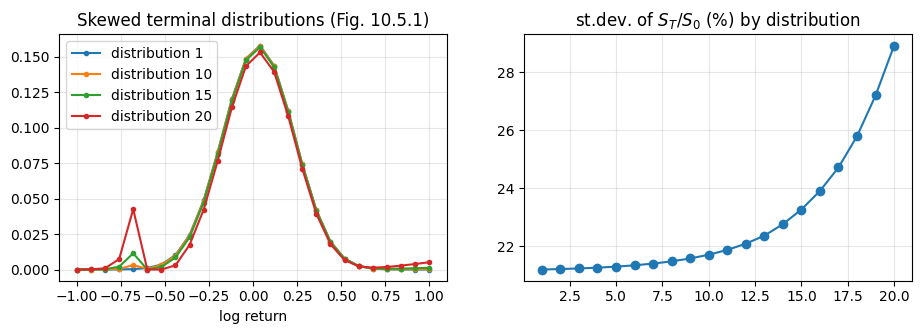

implied binomial tree for distribution 20: root = 100.0   p(0,0) = 0.5075 (CRR p = 0.5150)


In [53]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for k in (1, 10, 15, 20): ax[0].plot(np.log(ST / S0), dists[k - 1], marker=".", label=f"distribution {k}")
ax[0].set_title("Skewed terminal distributions (Fig. 10.5.1)"); ax[0].set_xlabel("log return"); ax[0].legend()
ax[1].plot(t105.dist, t105.sigma, "o-"); ax[1].set_title("st.dev. of $S_T/S_0$ (%) by distribution"); plt.show()
Sk, prk, _ = implied_binomial_tree(ST, dists[19], r, T / n); print("implied binomial tree for distribution 20: root =", round(Sk[0][0], 6), "  p(0,0) =", round(prk[0][0], 4), "(CRR p = %.4f)" % p)

## Chapter 11 — Pricing barrier options

In [54]:
CHAPTER = 11
def barrier_bs(S, K, H, T, r, sigma, kind="call", direction="down", knock="out", rebate=0.0, q=0.0):
    """Reiner-Rubinstein closed form (continuous monitoring), in Haug's A-F notation. Rebate: 'out' paid at hit, 'in' paid at expiry."""
    b = r - q; v = sigma * np.sqrt(T); mu = (b - sigma**2 / 2) / sigma**2; lam = np.sqrt(mu**2 + 2 * r / sigma**2)
    phi = 1 if kind == "call" else -1; eta = 1 if direction == "down" else -1
    if (direction == "down" and S <= H) or (direction == "up" and S >= H):          # already through the barrier
        return rebate if knock == "out" else bs_price(S, K, T, r, sigma, kind, q)
    x1 = np.log(S / K) / v + (1 + mu) * v; x2 = np.log(S / H) / v + (1 + mu) * v
    y1 = np.log(H**2 / (S * K)) / v + (1 + mu) * v; y2 = np.log(H / S) / v + (1 + mu) * v; z = np.log(H / S) / v + lam * v
    N = norm.cdf; eq, er = np.exp((b - r) * T), np.exp(-r * T)
    A = phi * S * eq * N(phi * x1) - phi * K * er * N(phi * x1 - phi * v)
    B = phi * S * eq * N(phi * x2) - phi * K * er * N(phi * x2 - phi * v)
    C = phi * S * eq * (H / S) ** (2 * (mu + 1)) * N(eta * y1) - phi * K * er * (H / S) ** (2 * mu) * N(eta * y1 - eta * v)
    D = phi * S * eq * (H / S) ** (2 * (mu + 1)) * N(eta * y2) - phi * K * er * (H / S) ** (2 * mu) * N(eta * y2 - eta * v)
    E = rebate * er * (N(eta * x2 - eta * v) - (H / S) ** (2 * mu) * N(eta * y2 - eta * v))
    F = rebate * ((H / S) ** (mu + lam) * N(eta * z) + (H / S) ** (mu - lam) * N(eta * z - 2 * eta * lam * v))
    above = K > H
    if knock == "in":
        core_ = {("call", "down"): (C if above else A - B + D), ("call", "up"): (A if above else B - C + D),
                 ("put", "down"): (B - C + D if above else A), ("put", "up"): (A - B + D if above else C)}[(kind, direction)]
        return core_ + E
    core_ = {("call", "down"): (A - C if above else B - D), ("call", "up"): (0.0 if above else A - B + C - D),
             ("put", "down"): (A - B + C - D if above else 0.0), ("put", "up"): (B - D if above else A - C)}[(kind, direction)]
    return core_ + F

# sanity checks of the closed form: in-out parity (Section 11.2) and three reference values from Haug's *Option Pricing Formulas*
for kind, direction, H in [("call", "up", 120), ("call", "down", 90), ("put", "down", 90), ("put", "up", 120)]:
    vi, vo = (barrier_bs(100, 110, H, 1, .05, .15, kind, direction, k) for k in ("in", "out"))
    print(f"{direction}-and-in {kind} {vi:8.4f} + {direction}-and-out {kind} {vo:8.4f} = {vi + vo:8.4f}   vanilla {bs_price(100, 110, 1, .05, .15, kind):8.4f}")
print("Haug reference values 9.0246 / 2.6789 / 2.9586:", round(barrier_bs(100, 90, 95, .5, .08, .25, "call", "down", "out", 3, q=.04), 4),
      round(barrier_bs(100, 90, 105, .5, .08, .25, "call", "up", "out", 3, q=.04), 4), round(barrier_bs(100, 90, 95, .5, .08, .25, "put", "down", "in", 3, q=.04), 4))

up-and-in call   3.7859 + up-and-out call   0.2900 =   4.0759   vanilla   4.0759
down-and-in call   0.1724 + down-and-out call   3.9035 =   4.0759   vanilla   4.0759
down-and-in put   6.7066 + down-and-out put   2.0045 =   8.7111   vanilla   8.7111
up-and-in put   0.2055 + up-and-out put   8.5056 =   8.7111   vanilla   8.7111
Haug reference values 9.0246 / 2.6789 / 2.9586: 9.0246 2.6789 2.9586


### Display 11.3.1 — values of various barrier options
The display gives spot = strike = 100 and one year to maturity but **neither the interest rate nor the volatility**.
For the first panel they can be backed out of the two vanilla prices it quotes (call 6.60, put 1.96): put-call parity gives $r$,
the call then gives $\sigma$. With those two numbers the closed-form (continuously monitored) barrier values reproduce the whole panel.
The second panel quotes a "straight call" of only 1.38, which is impossible for a one-year at-the-money call at that interest rate,
so it must refer to a shorter option; keeping $r$ and $\sigma$ from panel 1 and fitting the maturity gives about one month and again reproduces the panel.

In [55]:
r_d = -np.log((100 - (6.60 - 1.96)) / 100); s_d = brentq(lambda s: bs_price(100, 100, 1, r_d, s) - 6.60, .01, 1)
print(f"backed out of panel 1: r = {r_d:.4%}, sigma = {s_d:.4%}")
rows = []
for H, b_dip, b_doc in [(90, 1.38, 6.525), (92, 1.65, 6.36), (94, 1.84, 5.93), (96, 1.93, 4.98), (98, 1.96, 3.15), (100, 1.96, 0.0)]:
    dip = barrier_bs(100, 100, H, 1, r_d, s_d, "put", "down", "in"); doc = barrier_bs(100, 100, H, 1, r_d, s_d, "call", "down", "out")
    rows.append(dict(barrier=H, down_in_put=dip, book_dip=b_dip, down_out_call=doc, book_doc=b_doc))
    check(f"Display 11.3.1 down-and-in put, H = {H}", dip, b_dip, .008, note="r, sigma backed out of the quoted vanilla prices"); check(f"Display 11.3.1 down-and-out call, H = {H}", doc, b_doc, .008, note="r, sigma backed out of the quoted vanilla prices")
print(pd.DataFrame(rows).to_string(index=False, float_format="{:.3f}".format))

Hs = [100, 102, 104, 106, 108, 110, 112]; b_uo = [0, .06, .50, 1.02, 1.29, 1.36, 1.38]; b_ui = [1.38, 1.31, .87, .35, .09, 0, 0]
T_fit = brentq(lambda T: bs_price(100, 100, T, r_d, s_d) - 1.38, 1e-3, 1)
print(f"\npanel 2: maturity that makes the 'straight call' worth 1.38 with the same r and sigma: T = {T_fit:.4f} years ({365 * T_fit:.0f} days)")
rows = []
for H, bo, bi in zip(Hs, b_uo, b_ui):
    uo = barrier_bs(100, 100, H, T_fit, r_d, s_d, "call", "up", "out"); ui = barrier_bs(100, 100, H, T_fit, r_d, s_d, "call", "up", "in")
    rows.append(dict(barrier=H, up_out_call=uo, book_uo=bo, up_in_call=ui, book_ui=bi, in_plus_out=uo + ui))
    check(f"Display 11.3.1 up-and-out call, H = {H}", uo, bo, .012, note="maturity fitted: the panel's 1.38 'straight call' is not a one-year option")
    check(f"Display 11.3.1 up-and-in call, H = {H}", ui, bi, .02, note="maturity fitted: the panel's 1.38 'straight call' is not a one-year option")
print(pd.DataFrame(rows).to_string(index=False, float_format="{:.3f}".format))

backed out of panel 1: r = 4.7511%, sigma = 9.8665%
Display 11.3.1 down-and-in put, H = 90                     computed =      1.37746   book =       1.38   [OK]
Display 11.3.1 down-and-out call, H = 90                   computed =      6.52968   book =      6.525   [OK]
Display 11.3.1 down-and-in put, H = 92                     computed =      1.65404   book =       1.65   [OK]
Display 11.3.1 down-and-out call, H = 92                   computed =      6.36489   book =       6.36   [OK]
Display 11.3.1 down-and-in put, H = 94                     computed =      1.84165   book =       1.84   [OK]
Display 11.3.1 down-and-out call, H = 94                   computed =      5.93635   book =       5.93   [OK]
Display 11.3.1 down-and-in put, H = 96                     computed =      1.93290   book =       1.93   [OK]
Display 11.3.1 down-and-out call, H = 96                   computed =      4.98637   book =       4.98   [OK]
Display 11.3.1 down-and-in put, H = 98                     computed 

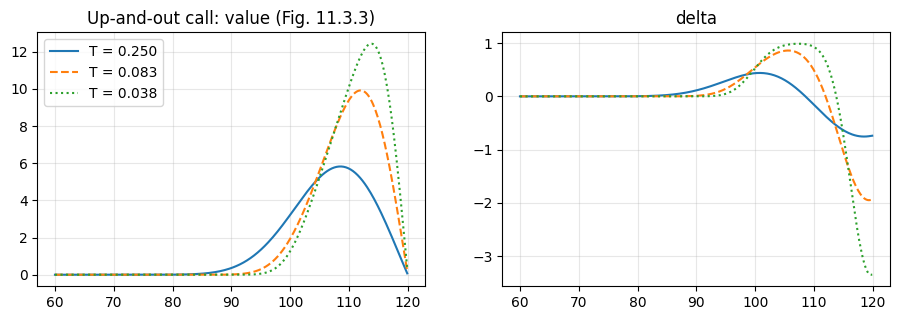

In [56]:
# Figure 11.3.3 re-drawn: up-and-out call, K = 100, H = 120, sigma = 15%, r = 5% — value and delta for three maturities
S = np.linspace(60, 119.9, 300); fig, ax = plt.subplots(1, 2, figsize=(11, 3.3))
for T_, ls in [(.25, "-"), (1 / 12, "--"), (2 / 52, ":")]:
    v = np.array([barrier_bs(s, 100, 120, T_, .05, .15, "call", "up", "out") for s in S]); ax[0].plot(S, v, ls, label=f"T = {T_:.3f}"); ax[1].plot(S, np.gradient(v, S), ls)
ax[0].set_title("Up-and-out call: value (Fig. 11.3.3)"); ax[1].set_title("delta"); ax[0].legend(); plt.show()

### Section 11.4 — barrier options on a binomial tree (Figures 11.4.2-11.4.9)
Backward induction "from the barrier": a node in the barrier region takes the value of the *target security* — the rebate for a
knock-out, the vanilla option (valued on the same tree) for a knock-in; terminal nodes that are still active pay the ordinary payoff
for a knock-out and nothing for a knock-in.

In [57]:
def barrier_tree(tree, probs, r, dt, K, kind, knock, up=None, down=None, rebate_up=0.0, rebate_down=0.0, american=False):
    pay = payoff_fn(K, kind); vanilla = backward(tree, probs, r, dt, pay, american)
    def target(i):                                   # value in the barrier region, NaN where the option is still 'inside'
        S = tree[i]; out = np.full(len(S), np.nan)
        if up is not None: out = np.where(S >= up, vanilla[i] if knock == "in" else rebate_up, out)
        if down is not None: out = np.where(S <= down, vanilla[i] if knock == "in" else rebate_down, out)
        return out
    n = len(tree) - 1; V = [None] * (n + 1); tg = target(n)
    V[n] = np.where(np.isnan(tg), pay(tree[n]) if knock == "out" else 0.0, tg)
    for i in range(n - 1, -1, -1):
        hold = np.exp(-r * dt) * (probs[i] * V[i + 1][1:] + (1 - probs[i]) * V[i + 1][:-1])
        if american and knock == "out": hold = np.maximum(hold, pay(tree[i]))
        tg = target(i); V[i] = np.where(np.isnan(tg), hold, tg)
    return V, vanilla
S0, r, sig, T, n = 100, .05, .20, 1.0, 4; dt = T / n; u, d, p = crr_params(sig, r, dt)
tree = standard_tree(S0, u, d, n); probs = [np.full(i + 1, p) for i in range(n)]
show_tree(tree, title="Figure 11.4.2"); check("p.457 risk-neutral p", p, .5378, 5e-5); check("p.458 one-period discount factor", np.exp(-r * dt), .9876, 5e-5)

Figure 11.4.2
    t0     t1     t2     t3     t4
                            149.18
                     134.99       
              122.14        122.14
       110.52        110.52       
100.00        100.00        100.00
        90.48         90.48       
               81.87         81.87
                      74.08       
                             67.03

p.457 risk-neutral p                                       computed =      0.53781   book =     0.5378   [OK]
p.458 one-period discount factor                           computed =      0.98758   book =     0.9876   [OK]


0.9875778004938814

In [58]:
# Example 1: knock-out call, K = 80, barrier 120, no rebate
V1, _ = barrier_tree(tree, probs, r, dt, 80, "call", "out", up=120); show_tree(V1, title="Example 1 (Figure 11.4.4)")
for (i, j), b in {(3, 2): 9.124, (3, 1): 11.4762, (3, 0): .9932, (2, 1): 10.09, (2, 0): 6.55, (1, 1): 4.61, (1, 0): 8.35, (0, 0): 6.26}.items(): check(f"Example 1 node ({i},{j})", V1[i][j], b, .011)
# Example 2: down-and-out put, K = 110, barrier 80, rebate $1
V2, van2 = barrier_tree(tree, probs, r, dt, 110, "put", "out", down=80, rebate_down=1.0); show_tree(V2, title="Example 2 (Figure 11.4.5)")
for (i, j), b in {(3, 3): 0.0, (3, 2): 4.56, (3, 1): 18.15, (3, 0): 1.0, (2, 2): 2.08, (2, 1): 10.71, (2, 0): 10.09, (1, 1): 5.99, (1, 0): 10.29, (0, 0): 7.88}.items(): check(f"Example 2 node ({i},{j})", V2[i][j], b, .011)
check("p.460 vanilla put at node (3,0)", van2[3][0], 34.56, .011); check("p.460 vanilla put payoff at (4,0)", van2[4][0], 42.97)

Example 1 (Figure 11.4.4)
  t0   t1    t2    t3    t4
                       0.00
                 0.00      
           0.00        0.00
     4.60        9.13      
6.26      10.09       20.00
     8.35       11.48      
           6.55        1.87
                 0.99      
                       0.00

Example 1 node (3,2)                                       computed =      9.12900   book =      9.124   [OK]
Example 1 node (3,1)                                       computed =     11.47752   book =     11.476   [OK]
Example 1 node (3,0)                                       computed =      0.99484   book =     0.9932   [OK]
Example 1 node (2,1)                                       computed =     10.08758   book =      10.09   [OK]
Example 1 node (2,0)                                       computed =      6.55012   book =       6.55   [OK]
Example 1 node (1,1)                                       computed =      4.60448   book =       4.61   [OK]
Example 1 node (1,0)             

42.967995396436095

In [59]:
# Example 3: knock-in call, K = 95, barrier 120
V3, van3 = barrier_tree(tree, probs, r, dt, 95, "call", "in", up=120); show_tree(V3, title="Example 3 (Figure 11.4.7)")
for (i, j), b in {(2, 2): 29.49, (4, 3): 27.14, (3, 2): 14.41, (3, 1): 0.0, (2, 1): 7.65, (1, 1): 19.16, (1, 0): 4.06, (0, 0): 12.03}.items(): check(f"Example 3 node ({i},{j})", V3[i][j], b, .011)
# Example 4: knock-in put, K = 110, barrier 82 (the summary table on p.456 says 85 — same nodes, same value)
V4, van4 = barrier_tree(tree, probs, r, dt, 110, "put", "in", down=82); show_tree(V4, title="Example 4: barrier option"); show_tree(van4, title="Example 4: vanilla put")
for (i, j), b in {(2, 0): 25.41, (4, 1): 28.13, (3, 1): 12.84, (2, 1): 5.86, (1, 1): 2.67, (1, 0): 14.71, (0, 0): 8.14}.items(): check(f"Example 4 knock-in node ({i},{j})", V4[i][j], b, .011)
for (i, j), b in {(0, 0): 10.07, (1, 0): 17.29, (1, 1): 5.99, (3, 0): 34.55, (4, 0): 42.97}.items():
    check(f"Example 4 vanilla node ({i},{j})", van4[i][j], b, .011, note="erratum: misprint, exp(-r dt)(p 5.99 + (1-p) 17.29) = 11.07" if (i, j) == (0, 0) else "")
print("value with the barrier at 85 instead of 82:", barrier_tree(tree, probs, r, dt, 110, "put", "in", down=85)[0][0][0])
# Example 5: double knock-out call, K = 90, up barrier 120 (rebate $2), down barrier 80 (rebate $5)
V5, _ = barrier_tree(tree, probs, r, dt, 90, "call", "out", up=120, down=80, rebate_up=2.0, rebate_down=5.0); show_tree(V5, title="Example 5 (Figure 11.4.9)")
for (i, j), b in {(3, 2): 5.63, (3, 1): 5.31, (2, 1): 5.41, (1, 1): 3.53, (1, 0): 5.20, (0, 0): 4.25}.items():
    check(f"Example 5 node ({i},{j})", V5[i][j], b, .011)
print("in-out parity on the tree (Example 3 strike):", V3[0][0] + barrier_tree(tree, probs, r, dt, 95, "call", "out", up=120)[0][0][0], "=", van3[0][0])

Example 3 (Figure 11.4.7)
   t0    t1    t2    t3    t4
                        54.18
                  41.17      
            29.49       27.14
      19.16       14.41      
12.03        7.66        0.00
       4.07        0.00      
             0.00        0.00
                   0.00      
                         0.00

Example 3 node (2,2)                                       computed =     29.48583   book =      29.49   [OK]
Example 3 node (4,3)                                       computed =     27.14028   book =      27.14   [OK]
Example 3 node (3,2)                                       computed =     14.41495   book =      14.41   [OK]
Example 3 node (3,1)                                       computed =      0.00000   book =          0   [OK]
Example 3 node (2,1)                                       computed =      7.65618   book =       7.65   [OK]
Example 3 node (1,1)                                       computed =     19.15540   book =      19.16   [OK]
Example 3 nod

### Section 11.5 — the enhanced numerical method (Figures 11.5.2-11.5.5)

In [60]:
# Figure 11.5.2: five-period tree, sigma = 15%, r = 5%, H = 120. The printed nodes (89.48, 145.88, 108.07, ...) identify it as an
# equal-probability tree with one-year steps: u = 1.2078, d = 0.8948
u_, d_, _ = eqprob_params(.15, .05, 1.0); t52 = standard_tree(100, u_, d_, 5); show_tree(t52, title="Figure 11.5.2")
for (i, j), bv in {(1, 0): 89.48, (2, 2): 145.88, (2, 1): 108.07, (3, 2): 130.52, (5, 5): 257.01, (5, 0): 57.35, (4, 2): 116.79}.items(): check(f"Fig 11.5.2 node ({i},{j})", t52[i][j], bv, .011)
check("Fig 11.5.2 node (1,1)", t52[1][1], 120.87, note="erratum: digits transposed, 100 u = 120.78")
eff = [min((s for s in lvl if s >= 120), default=np.nan) for lvl in t52]; mod = [max((s for s in lvl if s < 120), default=np.nan) for lvl in t52]
print("effective barrier by step:", np.round(eff, 2)); print("modified barrier by step :", np.round(mod, 2))

Figure 11.5.2
    t0     t1     t2     t3     t4     t5
                                   257.01
                            212.80       
                     176.19        190.40
              145.88        157.64       
       120.78        130.52        141.05
100.00        108.07        116.79       
        89.48         96.69        104.49
               80.06         86.52       
                      71.63         77.41
                             64.09       
                                    57.35

Fig 11.5.2 node (1,0)                                      computed =     89.47526   book =      89.48   [OK]
Fig 11.5.2 node (2,2)                                      computed =    145.87558   book =     145.88   [OK]
Fig 11.5.2 node (2,1)                                      computed =    108.06729   book =     108.07   [OK]
Fig 11.5.2 node (3,2)                                      computed =    130.52255   book =     130.52   [OK]
Fig 11.5.2 node (5,5)                    

In [61]:
def enhanced_knockout(tree, probs, r, dt, K, kind, H):
    """Up-and-out option with the Derman-Kani-Ergener-Bardhan correction, eq. (11.5.1).
    A node (i,j) lies on the modified barrier when the next node up at the same date, (i,j+1), lies on the effective barrier (S >= H).
    Its value is replaced by (H - Bm)/(Be - Bm) * V_e + (Be - H)/(Be - Bm) * V_m, where V_e comes from the plain effective-barrier
    tree and V_m = 0 (the node itself knocks out under the modified barrier); backward induction then continues from these nodes."""
    n = len(tree) - 1; Veff, _ = barrier_tree(tree, probs, r, dt, K, kind, "out", up=H); V = [v.copy() for v in Veff]
    for i in range(n - 1, -1, -1):
        S = tree[i]; hold = np.exp(-r * dt) * (probs[i] * V[i + 1][1:] + (1 - probs[i]) * V[i + 1][:-1]); V[i] = np.where(S >= H, 0.0, hold)
        for j in range(i):
            if S[j] < H <= S[j + 1]: V[i][j] = (H - S[j]) / (S[j + 1] - S[j]) * Veff[i][j]
    return V, Veff
S0, K, H, r, sig, T, n = 100, 90, 115, .05, .15, 1.0, 4; dt = T / n; u, d, p = crr_params(sig, r, dt)
tree = standard_tree(S0, u, d, n); probs = [np.full(i + 1, p) for i in range(n)]
V_book, Veff = enhanced_knockout(tree, probs, r, dt, K, "call", H)
show_tree(tree, title="Figure 11.5.4 stock tree"); show_tree(Veff, "{:.4f}", "effective-barrier values"); show_tree(V_book, "{:.4f}", "enhanced at the modified-barrier nodes A = (2,1) and B = (3,2)")
check("Fig 11.5.4 effective value, node B (3,2)", Veff[3][2], 4.2956, 5e-5); check("Fig 11.5.4 effective value, node A (2,1)", Veff[2][1], 4.7940, 5e-5)
check("p.473 enhanced node A", V_book[2][1], 4.444, 1e-3, note="the printed formula uses 107.7884 as modified barrier; the result (and the table) uses 100.00")
check("p.473 enhanced node B", V_book[3][2], 1.7759, 5e-5); check("Fig 11.5.5 node (3,1)", V_book[3][1], 5.5802, 5e-5); check("Fig 11.5.5 node (2,0)", V_book[2][0], 3.1138, 5e-5)
check("Fig 11.5.5 node (1,0)", V_book[1][0], 3.8171, 5e-5)
check("Fig 11.5.5 node (1,1)", V_book[1][1], 2.0593, 5e-4, note="erratum: 2.0593 is the un-enhanced value exp(-r dt)(1-p) x 4.7940; with the enhanced node A it is 1.9087")
check("Fig 11.5.5 option value", V_book[0][0], 2.8729, 5e-4, note="erratum: 2.8729 is the plain effective-barrier value; with nodes A and B enhanced the root is 2.7048")
print(f"\nup-and-out call, K = 90, H = 115 on the 4-step tree:  plain effective barrier {Veff[0][0]:.4f} | enhanced {V_book[0][0]:.4f}"
      f" | continuous-barrier closed form {barrier_bs(S0, K, H, T, r, sig, 'call', 'up', 'out'):.4f}  (four steps are far too few either way - see the next cell)")

Figure 11.5.4 stock tree
    t0     t1     t2     t3     t4
                            134.99
                     125.23       
              116.18        116.18
       107.79        107.79       
100.00        100.00        100.00
        92.77         92.77       
               86.07         86.07
                      79.85       
                             74.08

effective-barrier values
    t0     t1     t2     t3      t4
                             0.0000
                     0.0000        
              0.0000         0.0000
       2.0593        4.2956        
2.8729        4.7940        10.0000
       4.0127        5.5802        
              3.1138         0.0000
                     0.0000        
                             0.0000

enhanced at the modified-barrier nodes A = (2,1) and B = (3,2)
    t0     t1     t2     t3      t4
                             0.0000
                     0.0000        
              0.0000         0.0000
       1.9087        1.7759    

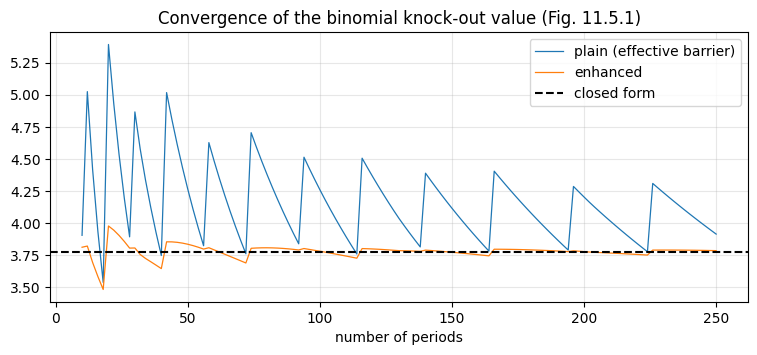

mean |error| over n = 10..250:  plain 0.3870   enhanced 0.0316


In [62]:
# Figure 11.5.1: saw-toothed convergence of the plain method, and what the enhancement does to it
def ko_values(nsteps):
    dt = T / nsteps; u, d, p = crr_params(sig, r, dt); tr = standard_tree(S0, u, d, nsteps); pr = [np.full(i + 1, p) for i in range(nsteps)]
    Va, Ve = enhanced_knockout(tr, pr, r, dt, K, "call", H); return Ve[0][0], Va[0][0]
ns = np.arange(10, 251, 2); vals = np.array([ko_values(k) for k in ns]); exact = barrier_bs(S0, K, H, T, r, sig, "call", "up", "out")
plt.figure(figsize=(9, 3.5)); plt.plot(ns, vals[:, 0], lw=.9, label="plain (effective barrier)"); plt.plot(ns, vals[:, 1], lw=.9, label="enhanced"); plt.axhline(exact, color="k", ls="--", label="closed form")
plt.xlabel("number of periods"); plt.title("Convergence of the binomial knock-out value (Fig. 11.5.1)"); plt.legend(); plt.show()
print(f"mean |error| over n = 10..250:  plain {np.abs(vals[:, 0] - exact).mean():.4f}   enhanced {np.abs(vals[:, 1] - exact).mean():.4f}")

## Reconciliation: computed versus book
`OK` = within the stated tolerance (normally half a unit of the last printed digit); `DIFF` = small differences explained in the note
(rounded intermediate values in the book, unspecified inputs); `ERRATUM` = the printed number is inconsistent with the book's own inputs.

In [63]:
res = pd.DataFrame(RESULTS)
summary = res.pivot_table(index="chapter", columns="status", values="item", aggfunc="count", fill_value=0)
summary["total"] = summary.sum(axis=1); summary.loc["all"] = summary.sum(); print(summary.to_string())
print(f"\n{(res.status == 'OK').mean():.1%} of the {len(res)} checked numbers are reproduced within tolerance.")

status   DIFF  ERRATUM   OK  total
chapter                           
1           0        0    9      9
2           0        0   17     17
3           0        0   20     20
4           0        1   45     46
5           0        0   21     21
6           0        3   64     67
7           0        3   62     65
8           0        0   30     30
9          10        0   39     49
10          0        3   61     64
11          0        4   87     91
all        10       14  455    479

95.0% of the 479 checked numbers are reproduced within tolerance.


In [64]:
pd.set_option("display.max_colwidth", 140)
print(res[res.status != "OK"][["chapter", "item", "computed", "book", "status", "note"]].to_string(index=False, float_format="{:.5g}".format))

 chapter                                        item  computed   book  status                                                                                                                                 note
       4                         p.167 vega, K = 110    11.294   5.47 ERRATUM                                     erratum: the vega of the 110 call is 11.29, not 5.47; the 1% rows inherit the slip ($0.113, 21%)
       6                  Fig 6.5.2 local volatility      0.01   0.15 ERRATUM                erratum: the figure repeats '15.00%' (and p = .5853 in one printing) from Fig 6.5.1; the tree has sigma = 1%, p = 1/2
       6                         p.238 equal-prob Su    100.58 110.94 ERRATUM                                                               erratum: Su must satisfy (Su + Sd)/2 = F, i.e. Su = 100.58, not 110.94
       6                            Fig 6.8.1 p(2,2)   0.68811 0.6811 ERRATUM                                                                               

In [65]:
res.to_csv("chriss_replication_checks.csv", index=False)          # full list of checks, for the record
res.head()

,chapter,item,computed,book,diff,status,note
0,1,p.21 units after 4 reinvested payments,1.050945,1.051,-0.000055,OK,
1,1,p.22 100 yen at 1% for one year,101.005017,101.005,0.000017,OK,
2,1,p.29 intrinsic value,5.000000,5.000,0.000000,OK,
3,1,p.29 time value,9.550000,9.550,0.000000,OK,
4,1,p.37 short-sale profit,11.518934,11.520,-0.001066,OK,


### What cannot be recomputed from the text
* **Tables 5.6.2-5.6.10, "Daily" column** — the daily stock paths are not printed (a Monte-Carlo illustration is given instead).
* **Section 8.5** — stochastic-volatility sample paths and histograms; the process and its parameters are not specified.
* **Figure 9.8.1** — reproduced in shape only (see the discussion in Chapter 9). **Tables 9.9.1-9.9.2 / Figure 9.9.1** — Goldman Sachs market data of 10/23/95.
* **Figure 10.1.1** — the illustrative call prices are not arbitrage-free, so no distribution exists that prices them.
* **Display 11.3.1** — reproduced only after backing $r$, $\sigma$ (and, for the second panel, the maturity) out of the quoted vanilla prices.